# MCDI501 — Estadística Computacional para la Toma de Decisiones
## Proyecto Transversal — Fase 1: Análisis Exploratorio e Inferencial

**Título del proyecto:** Análisis Exploratorio e Inferencial del Abandono Académico en Educación Superior

| Campo | Detalle |
|:---|:---|
| **Curso** | MCDI501 — Estadística Computacional para la Toma de Decisiones |
| **Docente** | Jean Paul Maidana González |
| **Grupo** | Grupo 7 |
| **Integrantes** | Juan de Dios Díaz Ríos · Francisco Fariña Molina · Constanza Moreno Giacometto · Yenne Sepúlveda Jerez |
| **Fecha** | Junio 2026 |
| **Dataset** | Predict Students' Dropout and Academic Success — UCI Machine Learning Repository |

---

## Índice

1. [Introducción](#1-introduccion)
2. [Aplicación de estadísticas descriptivas](#2-descriptivas)
   - 2.1 [Descripción del dataset y ficha descriptiva](#2.1-dataset)
   - 2.2 [Configuración del entorno](#2.2-entorno)
   - 2.3 [Carga y limpieza del dataset](#2.3-carga)
   - 2.4 [Reporte de valores faltantes](#2.4-nan)
   - 2.5 [Optimización de tipos de datos](#2.5-tipos)
   - 2.6 [Exploración preliminar](#2.6-exploracion)
   - 2.7 [Medidas descriptivas por tipo de variable](#2.7-variables)
   - 2.8 [Análisis bivariado y correlaciones](#2.8-bivariado)
3. [Estimación puntual e intervalos de confianza](#3-ic)
4. [Pruebas de hipótesis](#4-hipotesis)
   - 4.1 [Verificación de supuestos](#4.1-supuestos)
   - 4.2 [Prueba t para muestras independientes](#4.2-ttest)
   - 4.3 [Prueba chi-cuadrado de independencia](#4.3-chi2)
5. [Conclusiones](#5-conclusiones)
6. [Referencias](#6-referencias)

---

<a id='1-introduccion'></a>
## 1. Introducción

El abandono académico en la educación superior es un fenómeno complejo que afecta tanto a los estudiantes como a las instituciones educativas. El presente proyecto analiza el **Predict Students' Dropout and Academic Success Dataset** (Realinho et al., 2021), disponible en el UCI Machine Learning Repository, que contiene información sobre **4.424 estudiantes** distribuidos en **37 variables** que describen características demográficas, socioeconómicas, macroeconómicas y de desempeño académico. La variable objetivo (`Target`) clasifica cada estudiante en: **Graduate** (49,9 %), **Dropout** (32,1 %) y **Enrolled** (17,9 %).

> **Decisión técnica — Naturaleza del dataset:** Aunque el dataset contiene todos los registros de una institución específica entre 2008/2009 y 2018/2019, los autores (Realinho et al., 2022) lo construyeron para **generalizar a futuros estudiantes** mediante modelos predictivos. La población de interés es, por tanto, más amplia que los 4.424 registros observados. En consecuencia, el dataset se trata como una **muestra** y las medidas de dispersión se calculan con **pandas (`ddof=1`)**, aplicando la corrección de Bessel. Los intervalos de confianza y la prueba *t* son **estadísticamente válidos** bajo este enfoque.

---

<a id='2-descriptivas'></a>
## 2. Aplicación de estadísticas descriptivas

<a id='2.1-dataset'></a>
### 2.1 Descripción del dataset y ficha descriptiva

| Característica | Detalle |
|:---|:---|
| Fuente | UCI Machine Learning Repository |
| Archivo | `data_predict.csv` |
| Filas | 4.424 estudiantes |
| Columnas | 37 variables (36 predictoras + 1 objetivo) |
| Variable objetivo | `Target` — Graduate / Dropout / Enrolled |
| Separador | Punto y coma (`;`) |
| Naturaleza | **Muestra** (registros 2008/2009–2018/2019; población de interés: futuros estudiantes) |

---

#### Ficha descriptiva del proyecto

| Campo | Descripción |
|:---|:---|
| **Problema** | Identificar los factores estadísticamente asociados al abandono académico en educación superior, como base para el diseño de intervenciones de apoyo estudiantil oportunas |
| **Pregunta central** | ¿Existen diferencias estadísticamente significativas en el perfil académico, socioeconómico y demográfico entre estudiantes que se gradúan y estudiantes que desertan? |
| **Dataset** | Predict Students' Dropout and Academic Success (Realinho et al., 2021) |
| **Institución** | Institución de educación superior pública de Portugal |
| **Muestra** | 4.424 estudiantes (registros 2008/2009–2018/2019) |
| **Variable objetivo** | `Target` con tres categorías: Graduate (49,9 %), Dropout (32,1 %), Enrolled (17,9 %) |
| **Variables predictoras** | 36 variables: 18 nominales · 1 ordinal · 11 discretas · 7 continuas |
| **Período de análisis** | Primer y segundo semestre de la carrera de cada cohorte |

#### Relaciones preliminares identificadas

| Variable | Tipo | Relación esperada con deserción |
|:---|:---|:---|
| Curricular units 1st/2nd sem (approved) | Cuantitativa discreta | Inversa: mayor aprobación → menor riesgo de deserción |
| Curricular units 1st/2nd sem (grade) | Cuantitativa continua | Inversa: mejores notas → menor riesgo de deserción |
| Tuition fees up to date | Nominal binaria | Directa: arancel al día → menor riesgo de deserción |
| Debtor | Nominal binaria | Inversa: deudor → mayor riesgo de deserción |
| Scholarship holder | Nominal binaria | Directa: becado → menor riesgo de deserción |
| Age at enrollment | Cuantitativa discreta | Directa: mayor edad → mayor riesgo de deserción |
| Admission grade | Cuantitativa continua | Inversa: mayor nota de ingreso → menor riesgo de deserción |
| Previous qualification (grade) | Cuantitativa continua | Inversa: mayor calificación previa → menor riesgo |
| Gender | Nominal binaria | A explorar: posibles diferencias por género |
| Daytime/evening attendance | Nominal binaria | A explorar: jornada vespertina podría implicar mayor riesgo |

> **Nota metodológica:** estas relaciones son hipótesis preliminares basadas en el marco teórico de la deserción estudiantil. Su validación estadística se realiza en las secciones 3 y 4 del presente informe.

---

### Clasificación de variables

| (a) Cualitativa Nominal | (b) Cualitativa Ordinal | (c) Cuantitativa Discreta | (d) Cuantitativa Continua |
|:---|:---|:---|:---|
| Marital status | Application order | Age at enrollment | Previous qualification (grade) |
| Application mode | | Curricular units 1st sem (credited) | Admission grade |
| Course | | Curricular units 1st sem (enrolled) | Curricular units 1st sem (grade) |
| Daytime/evening attendance | | Curricular units 1st sem (evaluations) | Curricular units 2nd sem (grade) |
| Nationality | | Curricular units 1st sem (approved) | Unemployment rate |
| Mother's occupation | | Curricular units 1st sem (without evaluations) | Inflation rate |
| Father's occupation | | Curricular units 2nd sem (credited) | GDP |
| Displaced | | Curricular units 2nd sem (enrolled) | |
| Educational special needs | | Curricular units 2nd sem (evaluations) | |
| Debtor | | Curricular units 2nd sem (approved) | |
| Tuition fees up to date | | Curricular units 2nd sem (without evaluations) | |
| Gender | | | |
| Scholarship holder | | | |
| International | | | |
| Previous qualification | | | |
| Mother's qualification | | | |
| Father's qualification | | | |
| Target | | | |
| **18** | **1** | **11** | **7** |

> **Medidas válidas por tipo** (F1-2a):
> (a) Nominal → moda, proporción  ·  (b) Ordinal → moda, mediana, rango
> (c) Discreta → media, mediana, moda, σ, σ², IQR, asimetría, curtosis
> (d) Continua → ídem discreta + percentiles

> ### Decisión metodológica — Reclasificación de variables de calificación
>
> Las variables `Previous qualification`, `Mother's qualification` y `Father's qualification` se clasifican como **nominales**, no como ordinales, pese a estar codificadas con números.
>
> **Justificación:** sus códigos **no son monótonos respecto al nivel educativo**. Por ejemplo, en `Previous qualification` el código 1 es educación secundaria y el 5 es doctorado (orden ascendente), pero los códigos 9, 10, 12 y 14 corresponden a secundaria *incompleta* (nivel más bajo con código más alto). En `Mother's qualification`, el código 34 = "Unknown" (130 casos en los datos) aparece intercalado entre títulos universitarios. Calcular su mediana o rango (operaciones ordinales) daría resultados sin sentido, porque el orden numérico de los códigos no refleja un orden educativo real. Siguiendo el criterio de F1-2a — *"si calcular el promedio no tiene sentido en el contexto real, la variable es categórica aunque esté codificada con números"* — estas tres variables son **nominales administrativas** y solo admiten moda y frecuencias.
>
> `Application order` se mantiene como **ordinal**, porque sí tiene un orden genuino (0 = primera preferencia … 9 = última).

---

<a id='2.2-entorno'></a>
### 2.2 Configuración del entorno

---

In [1]:
# ============================================================
# REGISTRO DEL ENTORNO DE EJECUCIÓN
# ============================================================
import sys, platform

print("=" * 55)
print("ENTORNO DE EJECUCIÓN — Proyecto Grupo 7 MCDI501")
print("=" * 55)
print(f"Sistema operativo : {platform.system()} {platform.release()}")
print(f"Python            : {sys.version}")
print("=" * 55)

ENTORNO DE EJECUCIÓN — Proyecto Grupo 7 MCDI501
Sistema operativo : Windows 11
Python            : 3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]


In [2]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN GLOBAL
# ─────────────────────────────────────────────────────────────
# DECISIÓN numpy vs pandas (F1-2b):
#   pandas (ddof=1) → estadística MUESTRAL  ← este proyecto
#   numpy  (ddof=0) → estadística poblacional (no aplica aquí)
# ─────────────────────────────────────────────────────────────
# Seaborn: "opción recomendada para análisis exploratorio
#  y reportes estadísticos" (F1-3)
# ============================================================
import sys, os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats          # IC + prueba t


# ── Configuración global de Seaborn (F1-3: whitegrid + notebook)
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
sns.set_context("notebook")
plt.rcParams['figure.dpi'] = 100
plt.rcParams["font.family"] = "DejaVu Sans"
pd.options.display.float_format = '{:.4f}'.format
# __ Configuración para fijar la semilla del generador de números aleatorios de NumPy.
np.random.seed(42)
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"seaborn : {sns.__version__}")
print("✓ Entorno listo.")

pandas  : 3.0.3
numpy   : 2.4.6
seaborn : 0.13.2
✓ Entorno listo.


<a id='2.3-carga'></a>
### 2.3 Carga y limpieza del dataset

---

In [3]:
# ============================================================
# CARGA DEL DATASET
# ============================================================
sys.path.append(os.path.abspath("../src"))
from functions import *

RUTA_data = "../data/raw/data_original.csv"
df_data = cargar_dataset(RUTA_data)

# Normalizar nombres de columna (elimina tabuladores y espacios)
df_data.columns = (
    df_data.columns
    .str.replace("\t", "", regex=False)
    .str.strip()
)

print(f"  Filas    : {df_data.shape[0]:,}")
print(f"  Columnas : {df_data.shape[1]}")
print(f"  Columnas : {df_data.columns.tolist()}")

✓ Dataset cargado correctamente desde: ../data/raw/data_original.csv
  4,424 filas × 37 columnas
  Filas    : 4,424
  Columnas : 37
  Columnas : ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricula

<a id='2.4-binarizacion'></a>
### 2.4 Binarización de la variable objetivo


Originalmente el dataset presenta 3 posibles valores para la variable Target (Graduate,Enrolled,Dropout). Con el objetivo de poder predecir si el estudiante deserta o no del programa se requiere binarizar esta variable para ser utilizada posteriormente en una regresión logística y otro método de clasificación. A continuación se presenta la distribución original del dataset (Ver Gráfico 1):

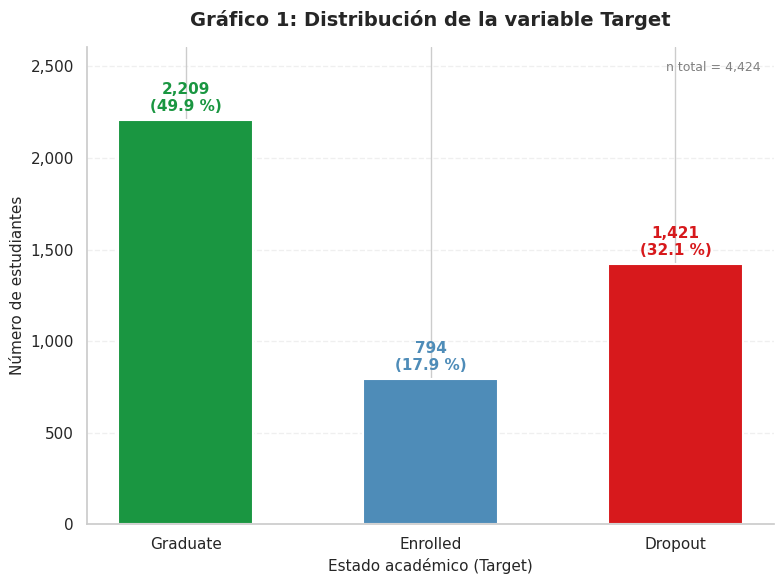

In [4]:
conteo = df_data['Target'].value_counts().reindex(['Graduate', 'Enrolled', 'Dropout'])
pct    = conteo / conteo.sum() * 100

COLORES = {'Graduate': '#1A9641', 'Enrolled': '#4E8CB8', 'Dropout': '#D7191C'}

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(conteo.index, conteo.values,
              color=[COLORES[c] for c in conteo.index],
              edgecolor='white', linewidth=1.5, width=0.55)

for bar, (cat, n) in zip(bars, conteo.items()):
    p = pct[cat]
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{n:,}\n({p:.1f} %)',
            ha='center', va='bottom', fontsize=11, fontweight='bold',
            color=COLORES[cat])

ax.set_title('Gráfico 1: Distribución de la variable Target', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Número de estudiantes', fontsize=11)
ax.set_xlabel('Estado académico (Target)', fontsize=11)
ax.set_ylim(0, conteo.max() * 1.18)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.text(0.98, 0.97, f'n total = {len(df_data):,}', transform=ax.transAxes,
        ha='right', va='top', fontsize=9, color='gray')
plt.tight_layout()
plt.subplots_adjust(wspace=0.45)
plt.show()

Para esta fase del proyecto se redefine el problema como una **clasificación binaria**, seleccionando únicamente los estudiantes con resultado académico definitivo: **Graduate** y **Dropout**. Se excluye la clase *Enrolled* dado que corresponde a estudiantes con proceso académico aún en curso, cuyo resultado final es desconocido e introduciría ruido en el análisis.

La nueva distribución de la variable objetivo presenta una razón de 1,55:1 entre clases (Graduate: 2.209 / Dropout: 1.421), lo que se considera **balanceada** para efectos del análisis. En clasificación binaria, el desbalance se considera problemático a partir de razones superiores a 5:1 o 10:1, umbrales que requerirían técnicas de remuestreo como SMOTE o *undersampling* para no sesgar el modelo hacia la clase mayoritaria. Con una razón de 1,55:1 no se requiere ningún tratamiento especial en esta fase.

| Clase | Codificación | N | % |
|---|---|---|---|
| Graduate | 1 | 2.209 | 60,9 % |
| Dropout | 0 | 1.421 | 39,1 % |
| **Total** | | **3.630** | 100 % |

Como resultado de la binarización, obtenemos el dataset (data_predict_binario.csv), el cual conserva las 37 variables originales e incorpora la columna Target_bin como variable objetivo para las etapas de análisis bivariado y modelamiento predictivo posteriores. Se detalla el código python necesario p ara incluir sólo los target Graduate y Dropout.

In [5]:
# ============================================================
# FILTRO BINARIO: Graduate vs Dropout
# Se excluye la clase 'Enrolled' por tener resultado académico # aún no determinado, quedando un problema de clasificación binaria.
# Graduate = 1 | Dropout = 0
# ============================================================

# Filtrar y codificar desde el dataset original en memoria
df_binario = df_data[df_data['Target'].isin(['Graduate', 'Dropout'])].copy()
df_binario['Target_bin'] = df_binario['Target'].map({'Graduate': 1, 'Dropout': 0})

# Guardar como nuevo CSV para uso en etapas posteriores
df_binario.to_csv(
    "../data/processed/data_predict_binario.csv",
    sep=";",
    index=False
)

# Verificación
print(f"Dataset original  : {len(df_data):,} estudiantes")
print(f"Dataset binario   : {len(df_binario):,} estudiantes")
print(f"Columnas          : {df_binario.shape[1]} (37 originales + Target_bin)")
print(f"\nDistribución de clases:")
print(df_binario['Target'].value_counts())
print(f"\nCodificación binaria:")
print(df_binario['Target_bin'].value_counts())

Dataset original  : 4,424 estudiantes
Dataset binario   : 3,630 estudiantes
Columnas          : 38 (37 originales + Target_bin)

Distribución de clases:
Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64

Codificación binaria:
Target_bin
1    2209
0    1421
Name: count, dtype: int64


<a id='2.5-tipo_datos'></a>
### 2.5 Verificar tipos de datos

Se verificó la estructura del conjunto de datos mediante info() y describe(), con el fin de validar los tipos de datos, la integridad de las variables y obtener un resumen estadístico inicial. Además, se comprobó la existencia de variables de tipo texto (object o string) para identificar posibles tratamientos adicionales antes del análisis.

In [6]:
print(df_binario.info())
print("\nVariables numéricas:")
print(df_binario.describe())
print("\nVariables categóricas:")
if df_binario.select_dtypes(include=['object', 'string']).empty:
    print("No se encontraron variables de tipo object o string.")
else:
    display(df_binario.describe(include=['object', 'string']))


<class 'pandas.DataFrame'>
Index: 3630 entries, 0 to 4423
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  3630 non-null   int64  
 1   Application mode                                3630 non-null   int64  
 2   Application order                               3630 non-null   int64  
 3   Course                                          3630 non-null   int64  
 4   Daytime/evening attendance                      3630 non-null   int64  
 5   Previous qualification                          3630 non-null   int64  
 6   Previous qualification (grade)                  3630 non-null   float64
 7   Nacionality                                     3630 non-null   int64  
 8   Mother's qualification                          3630 non-null   int64  
 9   Father's qualification                          3630 non-

,Target
count,3630
unique,2
top,Graduate
freq,2209


In [7]:
# Frecuencias de variables categóricas
for col in df_binario.select_dtypes(include=["object", "string"]).columns:
    print(f"\n{col}:")
    print(df_binario[col].value_counts())


Target:
Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64


**Hallazgos:** Los hallazgos al aplicar el análisis de este apartado 2.5, es: Los estudiantes ingresan a la institución/universidad con preferencia entre los primeros 3 lugares. Son estudiantes en estado civil soltero, provenientes de educación secundaria y también de otras instituciones/universidad. La cantidad de asignaturas inscritas en promedio son 6, y se aprueban 4 y el 50% (mediana) concentra una nota de aprobación de valor 12. Las notas están concentradas en el valor 10, es decir, muc Entre los estudiantes el nivel del desempleo está en torno al 11%, en donde la media y la mediana nos indican que los datos están concentrados. Otras variables, son analizadas en otros apartados más adelante.

<a id='2.6-tipos'></a>
### 2.6 Optimización de tipos de datos

Se aplican las conversiones de tipos de datos recomendadas, a modo de reducir/ahorrar memoria para una ejecución más eficiente:
- **Nominales** → `category` (se espera un ahorro estimado de hasta 90 % de memoria en columnas repetidas)
- **Ordinal/Discretas** → `int16` (rango −32 768 a 32 767, suficiente para todos los recuentos)
- **Continuas** → `float32` (7 dígitos de precisión, suficiente para escalas 0–200)
 ---
En la siguiente celda se aplican las conversiones según el tipo de datos, las variables son indicadas explícitamente. Mencionar que la nueva columna Target_bin, también fue incluida para pasarla a Category.


In [8]:
# ============================================================
# OPTIMIZACIÓN DE TIPOS DE DATOS (F1-2a)
# ============================================================

vars_cat = [                          # (a) Nominales → category
    'Marital status', 'Application mode', 'Course',
    'Daytime/evening attendance', 'Nacionality',
    "Mother's occupation", "Father's occupation",
    'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder',
    'International', 'Target', 'Target_bin',
    # Reclasificadas de ordinal a nominal (códigos administrativos no monótonos)
    'Previous qualification', "Mother's qualification", "Father's qualification",
]
vars_int16 = [                        # (b) Ordinal + (c) Discretas → int16
    'Application order',                 # única ordinal genuina
    'Age at enrollment',
    'Curricular units 1st sem (credited)',  'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',  'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (without evaluations)',
]
vars_float32 = [                      # (d) Continuas → float32
    'Previous qualification (grade)', 'Admission grade',
    'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'Inflation rate', 'GDP',
]

mem_antes = df_binario.memory_usage(deep=True).sum() / 1024**2

for col in vars_cat:
    if col in df_binario.columns:
        df_binario[col] = df_binario[col].astype('category')
for col in vars_int16:
    if col in df_binario.columns and df_binario[col].isnull().sum() == 0:
        df_binario[col] = df_binario[col].astype('int16')
for col in vars_float32:
    if col in df_binario.columns:
        df_binario[col] = df_binario[col].astype('float32')

mem_despues = df_binario.memory_usage(deep=True).sum() / 1024**2
print(f"Memoria antes    : {mem_antes:.2f} MB")
print(f"Memoria después  : {mem_despues:.2f} MB")
print(f"Reducción        : {(1 - mem_despues/mem_antes)*100:.1f} %")
print(f"\nTipos resultantes:\n{df_binario.dtypes.to_string()}")

Memoria antes    : 1.25 MB
Memoria después  : 0.28 MB
Reducción        : 77.9 %

Tipos resultantes:
Marital status                                    category
Application mode                                  category
Application order                                    int16
Course                                            category
Daytime/evening attendance                        category
Previous qualification                            category
Previous qualification (grade)                     float32
Nacionality                                       category
Mother's qualification                            category
Father's qualification                            category
Mother's occupation                               category
Father's occupation                               category
Admission grade                                    float32
Displaced                                         category
Educational special needs                         category
Debtor         

<a id='2.7-nan'></a>
### 2.7 Reporte de valores faltantes (NaN)

---

Se realizó una verificación sistemática de valores faltantes (NaN) para evaluar la integridad y calidad del conjunto de datos antes del análisis estadístico.Esta validación permite asegurar que los procedimientos posteriores se realicen sobre un conjunto de datos completo y confiable.

In [9]:
# ============================================================
# REPORTE DE VALORES FALTANTES — obligatorio antes de analizar
# ============================================================
nan_abs = df_binario.isnull().sum()
nan_pct = (nan_abs / len(df_binario) * 100).round(2)

reporte_nan = pd.DataFrame({
    'N NaN'  : nan_abs,
    '% NaN'  : nan_pct,
    'Tipo'   : df_binario.dtypes,
}).sort_values('N NaN', ascending=False)

print(f"Columnas con NaN : {(nan_abs > 0).sum()}")
print(f"Total NaN        : {nan_abs.sum():,}\n")

if nan_abs.sum() == 0:
    print("✓ No se detectaron valores faltantes.")
else:
    display(reporte_nan[reporte_nan['N NaN'] > 0])

Columnas con NaN : 0
Total NaN        : 0

✓ No se detectaron valores faltantes.


El dataset binarizado no presenta valores faltantes en ninguna de sus variables (0 NaN en las 37 columnas, n = 3.630).

<a id='2.8-exploracion'></a>
### 2.8 Exploración preliminar

---

Se visualizaron las primeras filas del dataset para verificar que la carga de los datos fuera correcta.
Esta revisión permitió conocer la estructura y el contenido inicial del conjunto de datos.
La exploración preliminar facilitó la detección temprana de posibles inconsistencias antes del análisis.

In [10]:
print("Primeras filas del dataset:")
mostrar_primeras_filas(df_binario, 10)

Primeras filas del dataset:

Primeras 10 filas:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Target_bin
0,1,17,5,171,1,1,122.0000,1,19,12,...,0,0,0,0.0000,0,10.8000,1.4000,1.7400,Dropout,0
1,1,15,1,9254,1,1,160.0000,1,1,3,...,6,6,6,13.6667,0,13.9000,-0.3000,0.7900,Graduate,1
2,1,1,5,9070,1,1,122.0000,1,37,37,...,6,0,0,0.0000,0,10.8000,1.4000,1.7400,Dropout,0
3,1,17,2,9773,1,1,122.0000,1,38,37,...,6,10,5,12.4000,0,9.4000,-0.8000,-3.1200,Graduate,1
4,2,39,1,8014,0,1,100.0000,1,37,38,...,6,6,6,13.0000,0,13.9000,-0.3000,0.7900,Graduate,1
5,2,39,1,9991,0,19,133.1000,1,37,37,...,5,17,5,11.5000,5,16.2000,0.3000,-0.9200,Graduate,1
6,1,1,1,9500,1,1,142.0000,1,19,38,...,8,8,8,14.3450,0,15.5000,2.8000,-4.0600,Graduate,1
7,1,18,4,9254,1,1,119.0000,1,37,37,...,5,5,0,0.0000,0,15.5000,2.8000,-4.0600,Dropout,0
8,1,1,3,9238,1,1,137.0000,62,1,1,...,6,7,6,14.1429,0,16.2000,0.3000,-0.9200,Graduate,1
9,1,1,1,9238,1,1,138.0000,1,1,19,...,6,14,2,13.5000,0,8.9000,1.4000,3.5100,Dropout,0


In [11]:
resumen_dataset(df_binario, nombre="Dataset data_predict")


  RESUMEN — Dataset data_predict
  Filas             : 3,630
  Columnas          : 38
  Duplicados        : 0
  Valores NaN total : 0

  Tipos de datos:
    category        : 19 columnas
    int16           : 12 columnas
    float32         : 7 columnas


<a id='2.9-variables'></a>
### 2.9 Medidas descriptivas por tipo de variable

**Criterio estadístico** : el dataset se trata como **muestra** — los modelos predictivos se generalizan a futuros estudiantes (Realinho et al., 2022).

| Estadístico | Fórmula | Librería | Cuándo |
|:---|:---|:---|:---|
| s (desv. estándar) | Divide por **n−1** | **`pandas` `ddof=1`** | **Muestra ← este análisis** |
| σ (desv. estándar) | Divide por **N** | `numpy` `ddof=0` | Solo si fuera población (no aplica) |
| Asimetría g₁ | Corrección muestral | **`pandas .skew()`** | **Muestra ← este análisis** |
| Curtosis g₂ | Corrección muestral | **`pandas .kurt()`** | **Muestra ← este análisis** |

Los gráficos usan **Seaborn** en todos los tipos de variable :
`sns.histplot` · `sns.countplot` · `sns.barplot`

---

#### Variables cuantitativas continuas

Medidas válidas: tendencia central + dispersión (σ, σ²) + forma (g₁, g₂).
Asimetría y curtosis son **exclusivas de variables cuantitativas** 

---

In [36]:
# ============================================================
# MEDIDAS DESCRIPTIVAS — VARIABLES CUANTITATIVAS CONTINUAS 
# pandas ddof=1 → MUESTRA 
# pandas .skew() y .kurt() → corrección muestral por defecto
# ============================================================

vars_continuas = [
    'Previous qualification (grade)', 'Admission grade',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

resumen_continuas = pd.DataFrame({
    'NaN':     df_binario[vars_continuas].isnull().sum(),
    'x̄':      df_binario[vars_continuas].mean(),
    'Mediana': df_binario[vars_continuas].median(),
    'Moda':    df_binario[vars_continuas].mode().iloc[0],
    's':       df_binario[vars_continuas].std(ddof=1),        # pandas — MUESTRA
    's²':      df_binario[vars_continuas].var(ddof=1),        # pandas — MUESTRA
    'Mín':     df_binario[vars_continuas].min(),
    'Máx':     df_binario[vars_continuas].max(),
    'Rango':   df_binario[vars_continuas].max() - df_binario[vars_continuas].min(),
    'Q1':      df_binario[vars_continuas].quantile(0.25),
    'Q3':      df_binario[vars_continuas].quantile(0.75),
    'IQR':     df_binario[vars_continuas].quantile(0.75) - df_binario[vars_continuas].quantile(0.25),
    'g₁':      df_binario[vars_continuas].skew(),             # pandas — corrección muestral
    'g₂':      df_binario[vars_continuas].kurt(),             # pandas — corrección muestral
}).round(4)

print("=== Medidas descriptivas — Continuas  | pandas ddof=1 (MUESTRA) ===")
resumen_continuas

=== Medidas descriptivas — Continuas  | pandas ddof=1 (MUESTRA) ===


,NaN,x̄,Mediana,Moda,s,s²,Mín,Máx,Rango,Q1,Q3,IQR,g₁,g₂
Previous qualification (grade),0,132.9206,133.1000,133.1000,13.2384,175.2545,95.0000,190.0000,95.0000,125.0000,140.0000,15.0000,0.2876,0.8946
Admission grade,0,127.2939,126.5000,130.0000,14.6113,213.4900,95.0000,190.0000,95.0000,118.0000,135.1000,17.1000,0.5077,0.5673
Curricular units 1st sem (grade),0,10.5349,12.3414,0.0000,5.0577,25.5803,0.0000,18.8750,18.8750,11.0000,13.5000,2.5000,-1.4519,0.4869
Curricular units 2nd sem (grade),0,10.0362,12.3333,0.0000,5.4817,30.0495,0.0000,18.5714,18.5714,10.5179,13.5000,2.9821,-1.1678,-0.3629
Unemployment rate,0,11.6304,11.1000,7.6000,2.6677,7.1164,7.6000,16.2000,8.6000,9.4000,13.9000,4.5000,0.1895,-1.0037
Inflation rate,0,1.2316,1.4000,1.4000,1.3849,1.9180,-0.8000,3.7000,4.5000,0.3000,2.6000,2.3000,0.2671,-1.0368
GDP,0,-0.0093,0.3200,0.3200,2.2600,5.1075,-4.0600,3.5100,7.5700,-1.7000,1.7900,3.4900,-0.3908,-0.9965


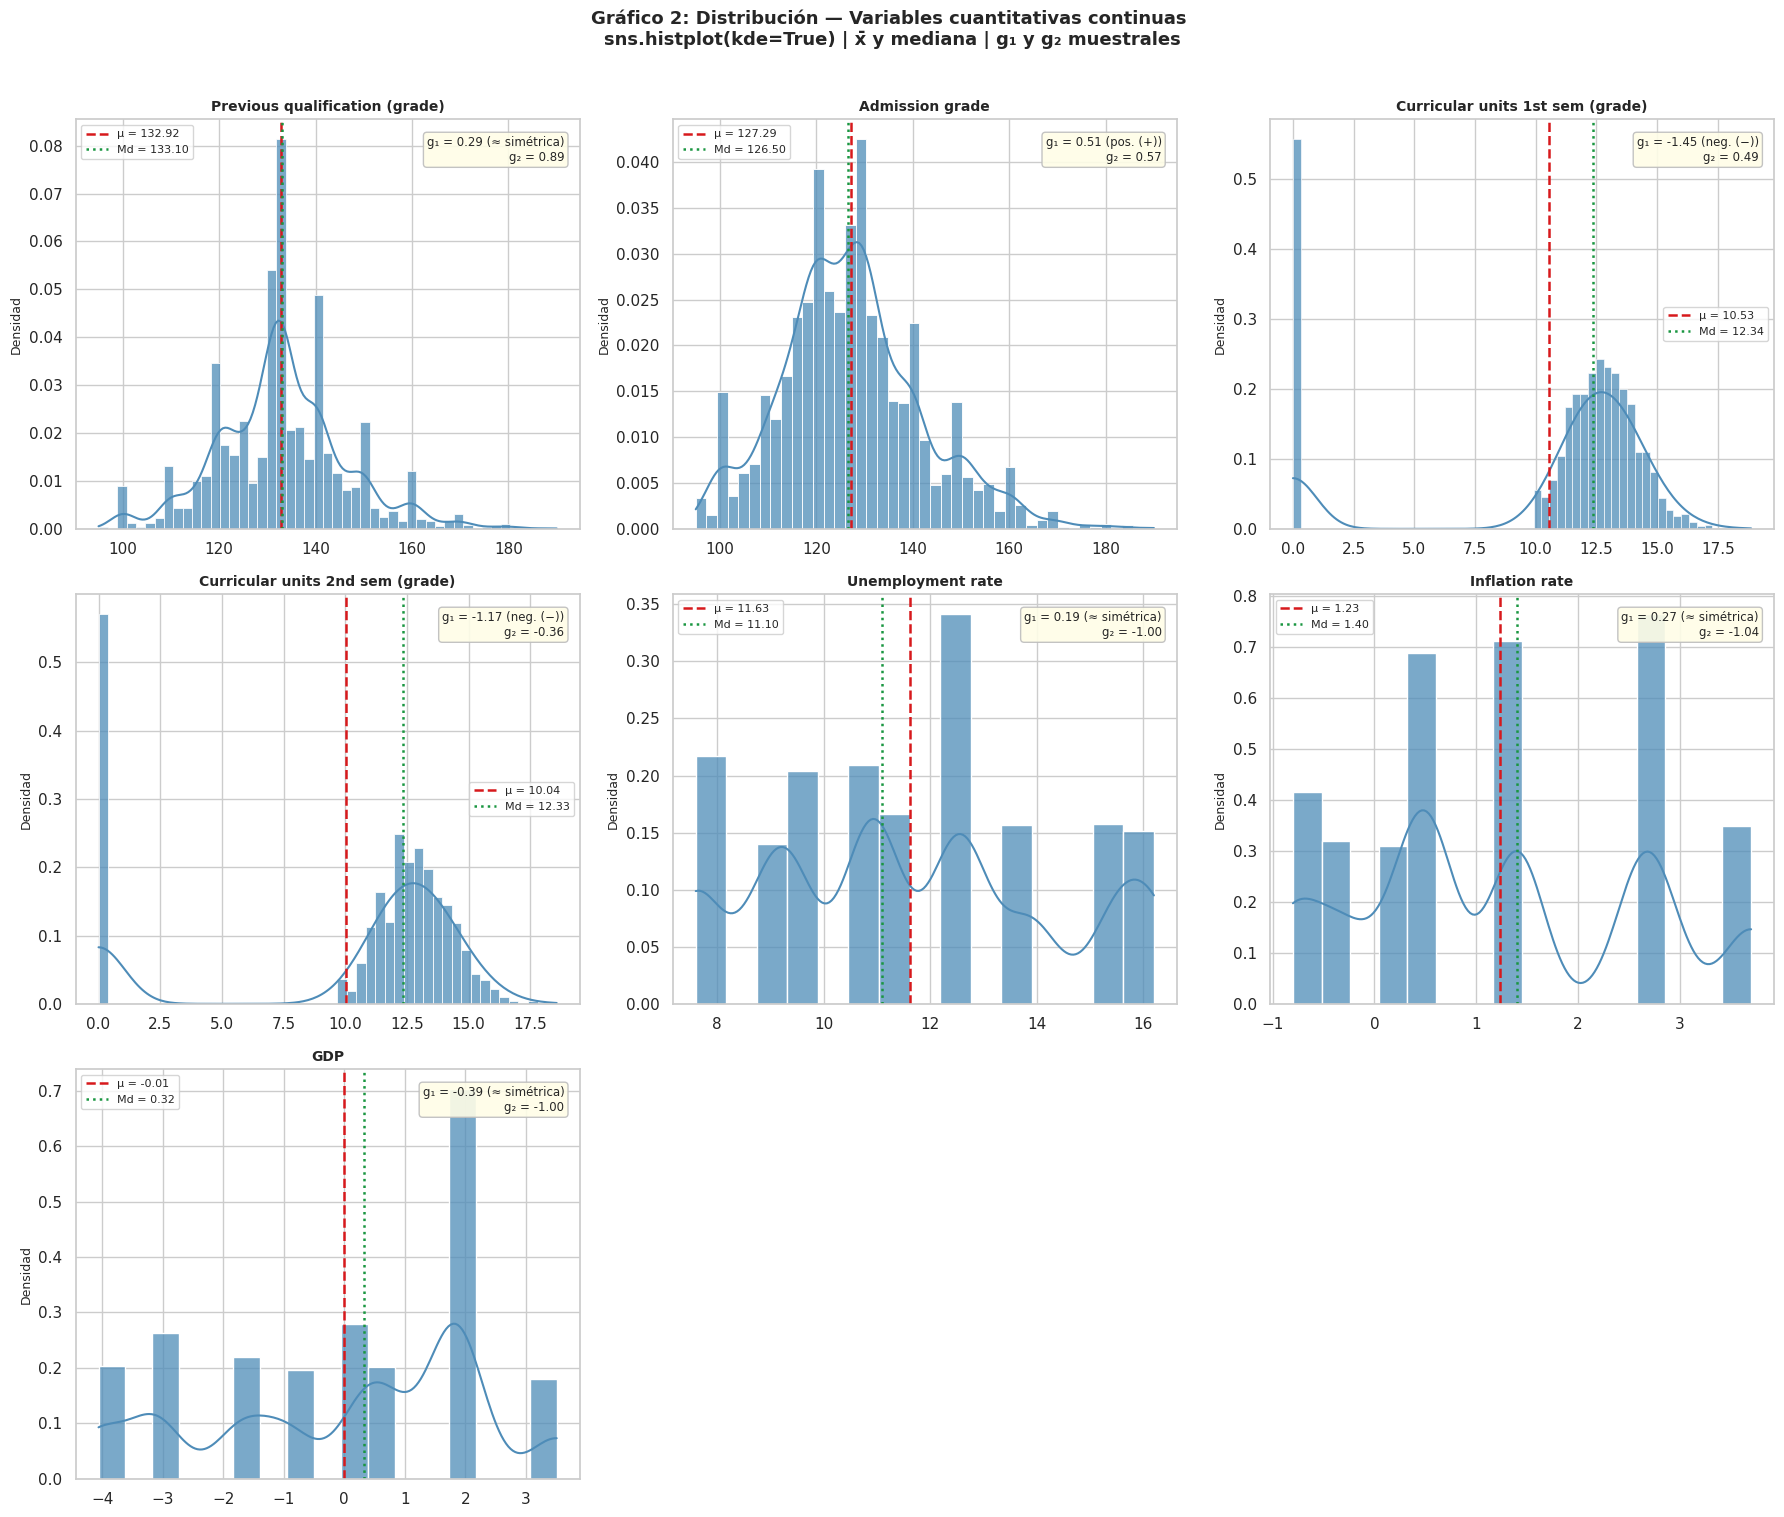

In [38]:
# ============================================================
# VISUALIZACIÓN —  VARIABLES CUANTITATIVAS CONTINUAS 
# sns.histplot(kde=True) : gráfico recomendado para 1 variable continua
# ============================================================

COLOR_HIST  = "#4E8CB8"
COLOR_MEDIA = "#D7191C"
COLOR_MED   = "#1A9641"

n_cols = 3
n_rows = math.ceil(len(vars_continuas) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(vars_continuas):
    ax    = axes[i]
    datos = df_binario[col].dropna().astype(float)

    sns.histplot(data=df_binario, x=col, kde=True, stat="density",
                 color=COLOR_HIST, edgecolor="white", alpha=0.75, ax=ax)

    mu  = float(datos.mean())
    med = float(datos.median())
    ax.axvline(mu,  color=COLOR_MEDIA, linestyle="--", lw=1.8,
               label=f"μ = {mu:.2f}")
    ax.axvline(med, color=COLOR_MED,   linestyle=":",  lw=1.8,
               label=f"Md = {med:.2f}")

    g1 = float(datos.skew())          # pandas — corrección muestral
    g2 = float(datos.kurt())          # pandas — corrección muestral
    asim = "≈ simétrica" if abs(g1) < 0.5 else ("pos. (+)" if g1 > 0 else "neg. (−)")
    ax.annotate(
        f"g₁ = {g1:.2f} ({asim})\ng₂ = {g2:.2f}",
        xy=(0.97, 0.96), xycoords="axes fraction",
        ha="right", va="top", fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.3", fc="#FFFDE7", ec="#BDBDBD", alpha=0.9)
    )

    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("Densidad", fontsize=9)
    ax.legend(fontsize=8)

for j in range(len(vars_continuas), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Gráfico 2: Distribución — Variables cuantitativas continuas \n"
             "sns.histplot(kde=True) | x̄ y mediana | g₁ y g₂ muestrales",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

#### Interpretación — Variables cuantitativas continuas

**Notas de ingreso (`Previous qualification (grade)` y `Admission grade`):**
Ambas variables presentan distribuciones aproximadamente simétricas (g₁ = 0,29 y 0,51 respectivamente), con medias cercanas a la mediana, lo que indica ausencia de valores extremos que distorsionen la tendencia central. La nota de calificación previa muestra menor dispersión (s = 13,24) que la nota de admisión (s = 14,61), sugiriendo mayor homogeneidad en el historial académico previo que en el proceso de selección. Las diferencias de media entre Graduate (134,1 y 128,8) y Dropout (131,1 y 125,0) son pequeñas, lo que anticipa un poder discriminante moderado de estas variables, confirmado posteriormente por el Cohen's d en la sección 4.2.

**Notas semestrales (`Curricular units 1st/2nd sem (grade)`):**
Son las variables continuas con mayor asimetría del análisis (g₁ = −1,45 y −1,17), con colas izquierdas pronunciadas explicadas por la alta concentración de calificaciones de 0 en el grupo Dropout (documentada en la sección 2.11). La media de Graduate casi duplica la de Dropout en primer semestre (12,64 vs 7,26) y la supera en más del doble en segundo semestre (12,70 vs 5,90), lo que señala al rendimiento en notas como uno de los predictores más potentes del resultado académico. La curtosis negativa en segundo semestre (g₂ = −0,36) indica una distribución con colas más ligeras que la normal, consistente con una separación bimodal entre quienes aprueban y quienes no rinden.

**Variables macroeconómicas (`Unemployment rate`, `Inflation rate`, `GDP`):**
Reflejan el contexto económico de Portugal entre 2008 y 2019. El desempleo presenta media de 11,63% con dispersión moderada (s = 2,67) y curtosis negativa (g₂ = −1,00), indicando distribución aplanada: no hay una tasa dominante, sino variación sostenida entre cohortes. La inflación muestra media de 1,23% con valores que van de −0,80% a 3,70%, y el PIB tiene media prácticamente nula (−0,01%) con registros negativos (mín = −4,06%), consistente con los años de recesión del período. Estas tres variables caracterizan el entorno externo al que se enfrentaron los estudiantes al momento del ingreso, cuya influencia sobre la deserción se contrasta en la sección 4.2.

#### Variables cuantitativas discretas

Continuando el análisis de las medidas descriptivas por el tipo de variable. Las variables discretas incluyen las mismas medidas que las continuas y se agregan la asimetría y curtosis (válidas para toda variable cuantitativa). s y s² calculadas con pandas `ddof=1` (muestra, corrección de Bessel).

---

In [40]:
# ============================================================
# MEDIDAS DESCRIPTIVAS — VARIABLES CUANTITATIVAS DISCRETAS 
# pandas ddof=1 → MUESTRA 
# ============================================================

vars_discreta = [
    'Age at enrollment',
    'Curricular units 1st sem (credited)',  'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',  'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (without evaluations)',
]

resumen_discretas = pd.DataFrame({
    'NaN':     df_binario[vars_discreta].isnull().sum(),
    'x̄':      df_binario[vars_discreta].mean(),
    'Mediana': df_binario[vars_discreta].median(),
    'Moda':    df_binario[vars_discreta].mode().iloc[0],
    's':       df_binario[vars_discreta].std(ddof=1),         # pandas — MUESTRA
    's²':      df_binario[vars_discreta].var(ddof=1),         # pandas — MUESTRA
    'Mín':     df_binario[vars_discreta].min(),
    'Máx':     df_binario[vars_discreta].max(),
    'Rango':   df_binario[vars_discreta].max() - df_binario[vars_discreta].min(),
    'IQR':     df_binario[vars_discreta].quantile(0.75) - df_binario[vars_discreta].quantile(0.25),
    'g₁':      df_binario[vars_discreta].skew(),              # pandas — corrección muestral
    'g₂':      df_binario[vars_discreta].kurt(),              # pandas — corrección muestral
}).round(4)

print("=== Medidas descriptivas — Discretas  | pandas ddof=1 (MUESTRA) ===")
resumen_discretas

=== Medidas descriptivas — Discretas  | pandas ddof=1 (MUESTRA) ===


,NaN,x̄,Mediana,Moda,s,s²,Mín,Máx,Rango,IQR,g₁,g₂
Age at enrollment,0,23.4612,20.0000,18,7.8280,61.2775,17,70,53,6.0000,1.9907,3.8031
Curricular units 1st sem (credited),0,0.7543,0.0000,0,2.4773,6.1369,0,20,20,0.0000,4.0646,17.9929
Curricular units 1st sem (enrolled),0,6.3375,6.0000,6,2.5708,6.6089,0,26,26,2.0000,1.6516,8.6261
Curricular units 1st sem (evaluations),0,8.0711,8.0000,8,4.2866,18.3752,0,45,45,4.0000,1.1461,6.0607
Curricular units 1st sem (approved),0,4.7915,5.0000,6,3.2378,10.4836,0,26,26,3.0000,0.7542,2.8667
Curricular units 1st sem (without evaluations),0,0.1289,0.0000,0,0.6791,0.4612,0,12,12,0.0000,8.7193,101.6870
Curricular units 2nd sem (credited),0,0.5818,0.0000,0,2.0227,4.0913,0,19,19,0.0000,4.4943,22.6507
Curricular units 2nd sem (enrolled),0,6.2964,6.0000,6,2.2630,5.1213,0,23,23,2.0000,0.8116,6.9111
Curricular units 2nd sem (evaluations),0,7.7631,8.0000,8,3.9642,15.7146,0,33,33,4.0000,0.3781,2.1217
Curricular units 2nd sem (approved),0,4.5185,5.0000,6,3.1624,10.0006,0,20,20,4.0000,0.2682,0.6657


Violinplot (7 vars): ['Age at enrollment', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)']
Barplot media (4 vars): ['Curricular units 1st sem (credited)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (without evaluations)']


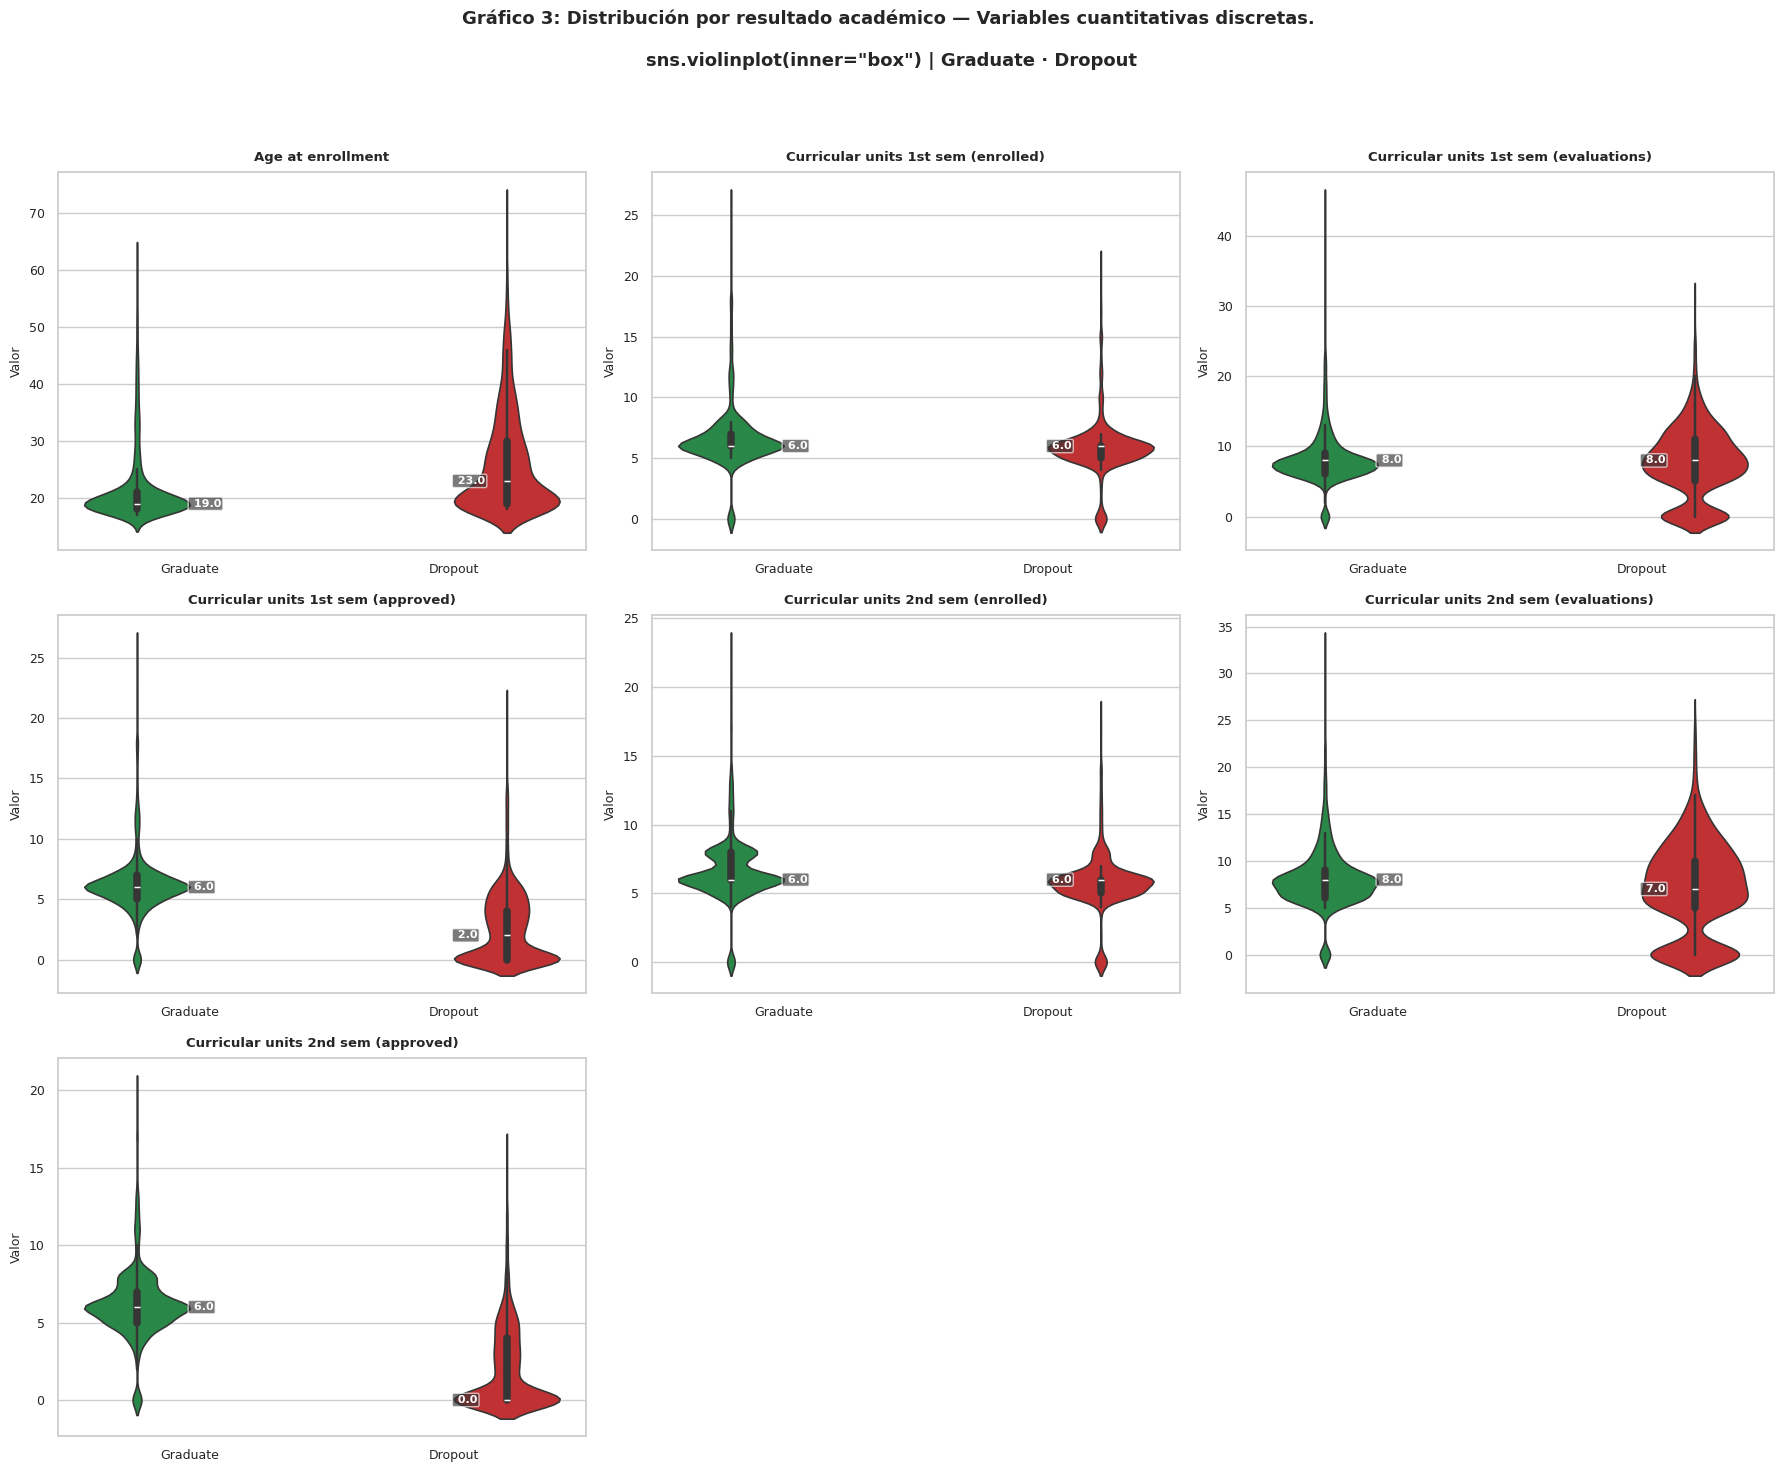

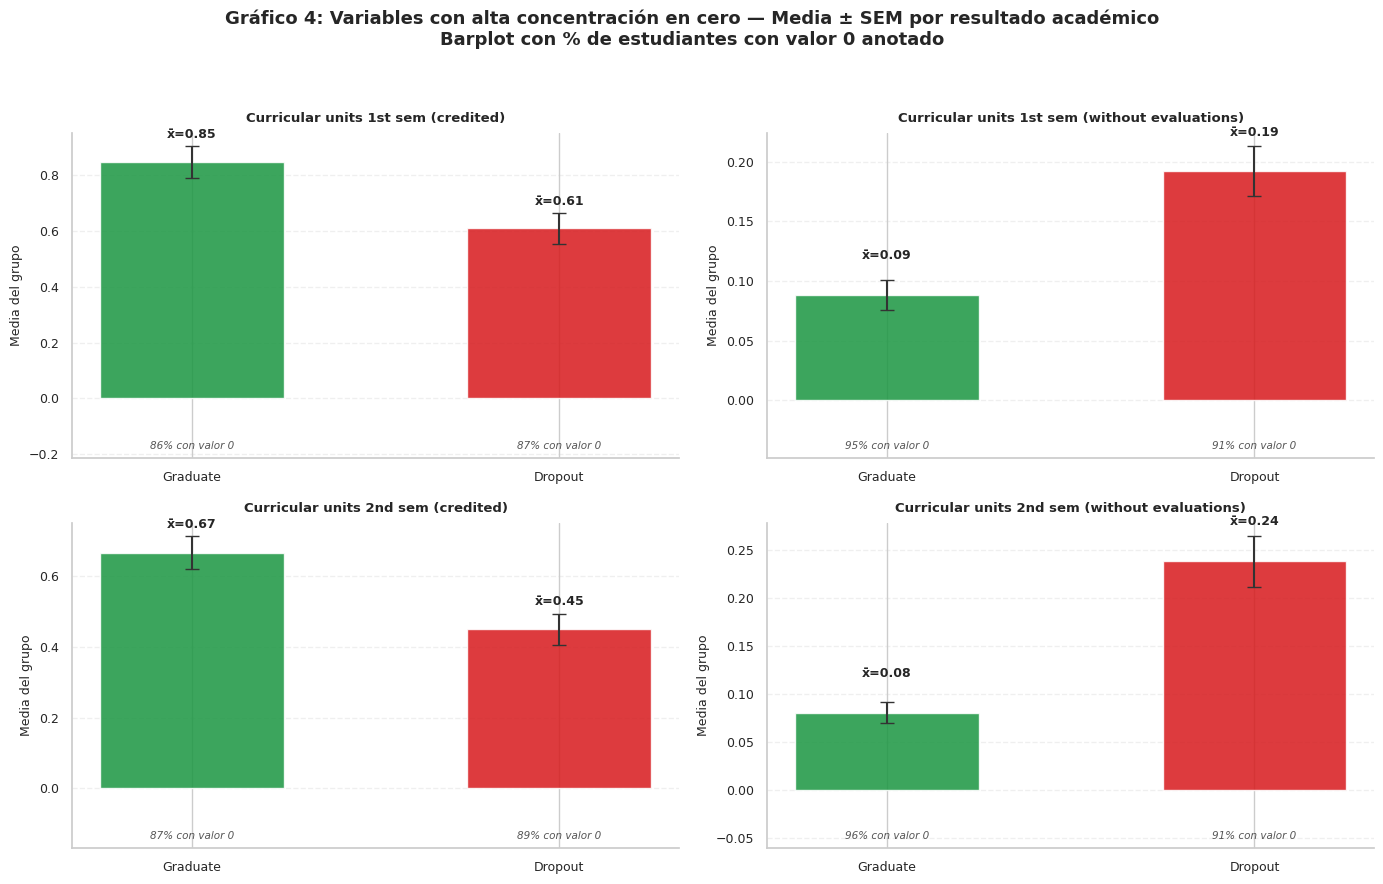

In [46]:
# ============================================================
# VISUALIZACIÓN — DISCRETAS 
# Clasificación automática por distribución:
#   Variables con > 40% de ceros → barplot de media ± SEM por Target
#   (el boxplot colapsa cuando casi todo el rango está en 0)
#   Resto → violinplot(inner='box') por Target
# ============================================================

import numpy as np

ORDEN_TARGET = ['Graduate', 'Dropout']
PAL_TARGET = {
    'Graduate': '#1A9641',
    'Dropout': '#D7191C'
}

# Clasificar automáticamente según concentración de ceros
vars_violin = [
    c for c in vars_discreta
    if (df_binario[c] == 0).mean() <= 0.40
]

vars_zero = [
    c for c in vars_discreta
    if (df_binario[c] == 0).mean() > 0.40
]

print(f"Violinplot ({len(vars_violin)} vars): {vars_violin}")
print(f"Barplot media ({len(vars_zero)} vars): {vars_zero}")

# ── Panel A: Violin con boxplot interior ─────────────────────
if vars_violin:
    n_cols = 3
    n_rows = math.ceil(len(vars_violin) / n_cols)

    fig_a, axes_a = plt.subplots(
        n_rows, n_cols,
        figsize=(18, 5 * n_rows)
    )

    axes_a = np.array(axes_a).flatten()

    for i, col in enumerate(vars_violin):

        ax = axes_a[i]

        datos_col = df_binario[['Target', col]].copy()
        datos_col[col] = datos_col[col].astype(float)

        sns.violinplot(
            data=datos_col,
            x='Target',
            y=col,
            order=ORDEN_TARGET,
            hue='Target',
            hue_order=ORDEN_TARGET,
            palette=PAL_TARGET,
            inner='box',
            legend=False,
            linewidth=1.2,
            ax=ax
        )

        # Mediana anotada
        for j, grupo in enumerate(ORDEN_TARGET):

            med = datos_col.loc[
                datos_col['Target'] == grupo, col
            ].median()

            ax.text(
                j,
                med,
                f' {med:.1f}',
                va='center',
                ha='left',
                fontsize=8,
                fontweight='bold',
                color='white',
                bbox=dict(
                    boxstyle='round,pad=0.15',
                    fc='#333333',
                    alpha=0.65
                )
            )

        ax.set_title(col, fontsize=9.5, fontweight='bold', pad=8)
        ax.set_xlabel('')
        ax.set_ylabel('Valor', fontsize=9)
        ax.tick_params(labelsize=9)

    for j in range(len(vars_violin), len(axes_a)):
        fig_a.delaxes(axes_a[j])

    fig_a.suptitle(
        'Gráfico 3: Distribución por resultado académico — Variables cuantitativas discretas. \n\n'
        'sns.violinplot(inner="box") | Graduate · Dropout',
        fontsize=13,
        fontweight='bold'
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    plt.show()

# ── Panel B: Barplot media ± SEM para variables con muchos ceros ──
if vars_zero:

    n_cols = 2
    n_rows = math.ceil(len(vars_zero) / n_cols)

    fig_b, axes_b = plt.subplots(
        n_rows, n_cols,
        figsize=(14, 4.5 * n_rows)
    )

    axes_b = np.array(axes_b).flatten()

    for i, col in enumerate(vars_zero):

        ax = axes_b[i]

        medias = []

        for grupo in ORDEN_TARGET:

            sub = (
                df_binario[df_binario['Target'] == grupo][col]
                .dropna()
                .astype(float)
            )

            medias.append({
                'Grupo': grupo,
                'Media': sub.mean(),
                'SEM': sub.sem(),
                'pct0': (sub == 0).mean() * 100
            })

        df_m = pd.DataFrame(medias)

        bars = ax.bar(
            df_m['Grupo'],
            df_m['Media'],
            color=[PAL_TARGET[g] for g in df_m['Grupo']],
            edgecolor='white',
            alpha=0.85,
            width=0.5
        )

        ax.errorbar(
            df_m['Grupo'],
            df_m['Media'],
            yerr=df_m['SEM'],
            fmt='none',
            color='#333333',
            capsize=5,
            linewidth=1.5
        )

        # Valor de la media sobre cada barra
        for bar, (_, row) in zip(bars, df_m.iterrows()):

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + df_m['SEM'].max() * 1.3,
                f'x̄={row["Media"]:.2f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

        # Porcentaje con valor 0 debajo del eje
        ymin = -df_m['Media'].max() * 0.18

        for j, (_, row) in enumerate(df_m.iterrows()):

            ax.text(
                j,
                ymin,
                f'{row["pct0"]:.0f}% con valor 0',
                ha='center',
                va='top',
                fontsize=7.5,
                color='#555555',
                style='italic'
            )

        ax.set_title(col, fontsize=9.5, fontweight='bold', pad=8)
        ax.set_xlabel('')
        ax.set_ylabel('Media del grupo', fontsize=9)
        ax.set_ylim(bottom=ymin * 1.4)
        ax.tick_params(labelsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for j in range(len(vars_zero), len(axes_b)):
        fig_b.delaxes(axes_b[j])

    fig_b.suptitle(
        'Gráfico 4: Variables con alta concentración en cero — Media ± SEM por resultado académico\n'
        'Barplot con % de estudiantes con valor 0 anotado',
        fontsize=13,
        fontweight='bold'
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

      

#### Interpretación — Variables cuantitativas discretas

**Unidades aprobadas (`approved` — 1.° y 2.° semestre):**
Son las variables más discriminantes del análisis. En primer semestre, Graduate tiene mediana de 6 unidades aprobadas (media = 6,23) frente a Dropout con mediana de 2 (media = 2,55). La brecha se amplía en segundo semestre: Graduate mantiene mediana de 6 (media = 6,18) mientras Dropout cae a mediana de 0 (media = 1,94). El 22,1% de los registros de segundo semestre tiene 0 unidades aprobadas, concentrado en el grupo Dropout. Esta progresión indica que el desenganche académico se profundiza a lo largo del año y que el segundo semestre actúa como punto de quiebre crítico.

**Unidades inscritas (`enrolled`) y evaluaciones (`evaluations`):**
Ambas variables muestran diferencias mucho menores entre grupos. La mediana de unidades inscritas es idéntica en Graduate y Dropout (6 en ambos semestres), y las evaluaciones son casi iguales (mediana 8 vs 7-8). Esto indica que los estudiantes que desertan no se inscriben en menos ramos ni evitan rendir evaluaciones en la misma proporción que los que no aprueban. El problema no es cuánto se intenta, sino cuánto se logra.

**Edad al ingreso (`Age at enrollment`):**
Los Dropout presentan una mediana de 23 años (media = 26,07) frente a los Graduate con mediana de 19 años (media = 21,78). La distribución tiene fuerte asimetría positiva (g₁ = 1,99) y rango amplio (17–70 años), reflejando la presencia de estudiantes adultos que reingresan al sistema. La mayor edad al ingreso en el grupo desertor es consistente con la literatura sobre mayor vulnerabilidad académica en estudiantes no tradicionales.

**Unidades acreditadas (`credited`) y sin evaluación (`without evaluations`):**
Ambas variables están fuertemente concentradas en cero (`credited`: 86,8% de ceros; `without evaluations`: 93,8%), con asimetrías extremas (g₁ = 4,07 y 8,72 respectivamente). Los valores distintos de cero corresponden a casos especiales de convalidación o situaciones de licencia académica. No discriminan entre Graduate y Dropout y tienen valor descriptivo marginal para el problema de deserción.

> **Relación con el problema:** la comparación entre unidades inscritas (sin diferencia entre grupos) y unidades aprobadas (diferencia pronunciada y creciente entre semestres) define el mecanismo central del abandono en este dataset: los estudiantes en riesgo intentan, pero no logran. El primer semestre es el período de detección temprana clave; el segundo semestre confirma o profundiza la trayectoria.

---

#### Interpretación — Variables con alta concentración de ceros

Las variables **`Curricular units credited`** y **`Curricular units without evaluations`** presentan una elevada concentración de observaciones iguales a cero (86–89 % en `credited` y 91–96 % en `without evaluations`), por lo que se representan mediante **barplots de la media ± error estándar (SEM)** en lugar de boxplots.

- **`Curricular units credited` (1.° y 2.° semestre):** los estudiantes **Graduate** presentan una media ligeramente superior de unidades convalidadas respecto de los **Dropout** (0,85 vs. 0,61 en primer semestre y 0,67 vs. 0,45 en segundo). Sin embargo, en ambos grupos más del 86 % registra valor igual a cero, lo que indica que la convalidación de asignaturas es un fenómeno poco frecuente y con diferencias de magnitud pequeña entre grupos.

- **`Curricular units without evaluations` (1.° y 2.° semestre):** los estudiantes **Dropout** presentan una media de unidades inscritas sin evaluación entre 2,2 y 2,9 veces superior a la de los **Graduate** (0,19 vs. 0,09 en primer semestre y 0,24 vs. 0,08 en segundo). Aunque la mayoría registra valor cero, esta diferencia relativa sugiere que abandonar asignaturas antes de ser evaluadas es más frecuente entre quienes posteriormente desertan, y se acentúa en el segundo semestre.

> **Relación con el problema:** aunque ambas variables tienen escasa variabilidad, las **unidades sin evaluación** aportan más información diferenciadora que las **unidades convalidadas**. El patrón de inscribirse y no rendir evaluaciones puede constituir una señal temprana de desvinculación académica previa al abandono formal.

#### Variables cualitativas ordinales

Tras la reclasificación de las variables de calificación a nominales, la **única variable ordinal genuina** del dataset es `Application order` (orden de preferencia de postulación: 0 = primera opción … 9 = última).

Medidas válidas: **moda, mediana y rango** . No se calculan media, σ, asimetría ni curtosis porque las distancias entre categorías no son necesariamente iguales.

---

In [ ]:
# ============================================================
# MEDIDAS DESCRIPTIVAS — ORDINAL 
# Única ordinal genuina: Application order
# Válidas: moda, mediana, rango | NO: media, σ, asimetría (F1-2a)
# ============================================================

vars_ordinal = ['Application order']

resumen_ordinales = pd.DataFrame({
    'NaN':     df_binario[vars_ordinal].isnull().sum(),
    'Moda':    df_binario[vars_ordinal].apply(lambda x: x.value_counts().idxmax()),
    'Mediana': df_binario[vars_ordinal].median(),
    'Mín':     df_binario[vars_ordinal].min(),
    'Máx':     df_binario[vars_ordinal].max(),
    'Rango':   df_binario[vars_ordinal].max() - df_binario[vars_ordinal].min(),
}).round(2)

print("=== Medidas descriptivas — Ordinal (b) | Moda · Mediana · Rango ===")
resumen_ordinales

=== Medidas descriptivas — Ordinal (b) | Moda · Mediana · Rango ===


,NaN,Moda,Mediana,Mín,Máx,Rango
Application order,0,1,1.0000,0,6,6


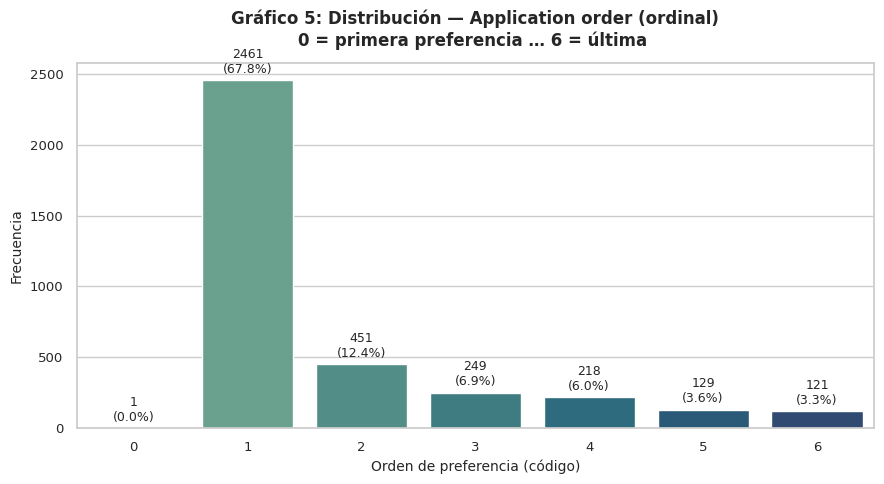

In [47]:
# ============================================================
# VISUALIZACIÓN — ORDINAL 
# Application order: countplot ordenado por código (respeta jerarquía)
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

col   = 'Application order'
datos = df_binario[col].astype(str)
orden = [str(v) for v in sorted(df_binario[col].unique())]
total = int(df_binario[col].count())

sns.countplot(
    data=df_binario.assign(**{col: datos}),
    x=col, order=orden,
    hue=col, hue_order=orden,
    palette='crest',
    legend=False,
    edgecolor='white',
    ax=ax
)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width()/2, h + total * 0.008,
                f"{int(h)}\n({h/total*100:.1f}%)",
                ha='center', va='bottom', fontsize=9)

ax.set_title('Gráfico 5: Distribución — Application order (ordinal)\n'
             '0 = primera preferencia … 6 = última ',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Orden de preferencia (código)', fontsize=10)
ax.set_ylabel('Frecuencia', fontsize=10)
ax.tick_params(labelsize=9.5)
plt.tight_layout()
plt.show()

#### Interpretación — Variable ordinal

- **`Application order`**: el 67,8% de los estudiantes ingresó como segunda preferencia (código 1), siendo esta la categoría ampliamente dominante. La distribución cae progresivamente desde el código 2 al 6, con frecuencias cada vez menores. Esto podría tener implicancias en la motivación y compromiso inicial del estudiante con su programa, factores que en las secciones siguientes se relacionarán con el riesgo de deserción.

> **Nota:** las variables de calificación del estudiante y de los padres, que en una primera aproximación podrían parecer ordinales, se analizan como **nominales** (ver sección 2.7 y la decisión metodológica en la sección 2.1), porque sus códigos no representan una escala ordenada real.

---

#### Variables cualitativas nominales

Medidas válidas: **moda y frecuencias** . No se calculan media, mediana, σ, asimetría ni curtosis.

---

In [ ]:
# ============================================================
# MEDIDAS DESCRIPTIVAS — NOMINALES 
# Válidas: moda y frecuencias | NO: media, mediana, σ 
# Incluye las 3 variables de calificación reclasificadas a nominal
# ============================================================

vars_nominales = [
    'Marital status', 'Application mode', 'Course',
    'Daytime/evening attendance', 'Nacionality',
    "Mother's occupation", "Father's occupation",
    'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder',
    'International', 'Target_bin',
    # Reclasificadas de ordinal a nominal (códigos administrativos no monótonos)
    'Previous qualification', "Mother's qualification", "Father's qualification",
]

resumen_nominales = pd.DataFrame({
    'NaN':        df_binario[vars_nominales].isnull().sum(),
    'N únicas':   df_binario[vars_nominales].nunique(),
    'Moda':       df_binario[vars_nominales].apply(lambda x: x.value_counts().idxmax()),
    'Frec. Moda': df_binario[vars_nominales].apply(lambda x: x.value_counts().max()),
    '% Moda':     (df_binario[vars_nominales].apply(lambda x: x.value_counts().max())
                   / len(df_binario) * 100).round(1),
})

print("=== Medidas descriptivas — Nominales (a) | Moda y Frecuencias ===")
print(f"Total variables nominales: {len(vars_nominales)}")
resumen_nominales

=== Medidas descriptivas — Nominales (a) | Moda y Frecuencias ===
Total variables nominales: 18


,NaN,N únicas,Moda,Frec. Moda,% Moda
Marital status,0,6,1,3199,88.1000
Application mode,0,18,1,1408,38.8000
Course,0,17,9500,666,18.3000
Daytime/evening attendance,0,2,1,3222,88.8000
Nacionality,0,19,1,3544,97.6000
Mother's occupation,0,29,9,1313,36.2000
Father's occupation,0,42,9,847,23.3000
Displaced,0,2,1,1993,54.9000
Educational special needs,0,2,0,3590,98.9000
Debtor,0,2,0,3217,88.6000


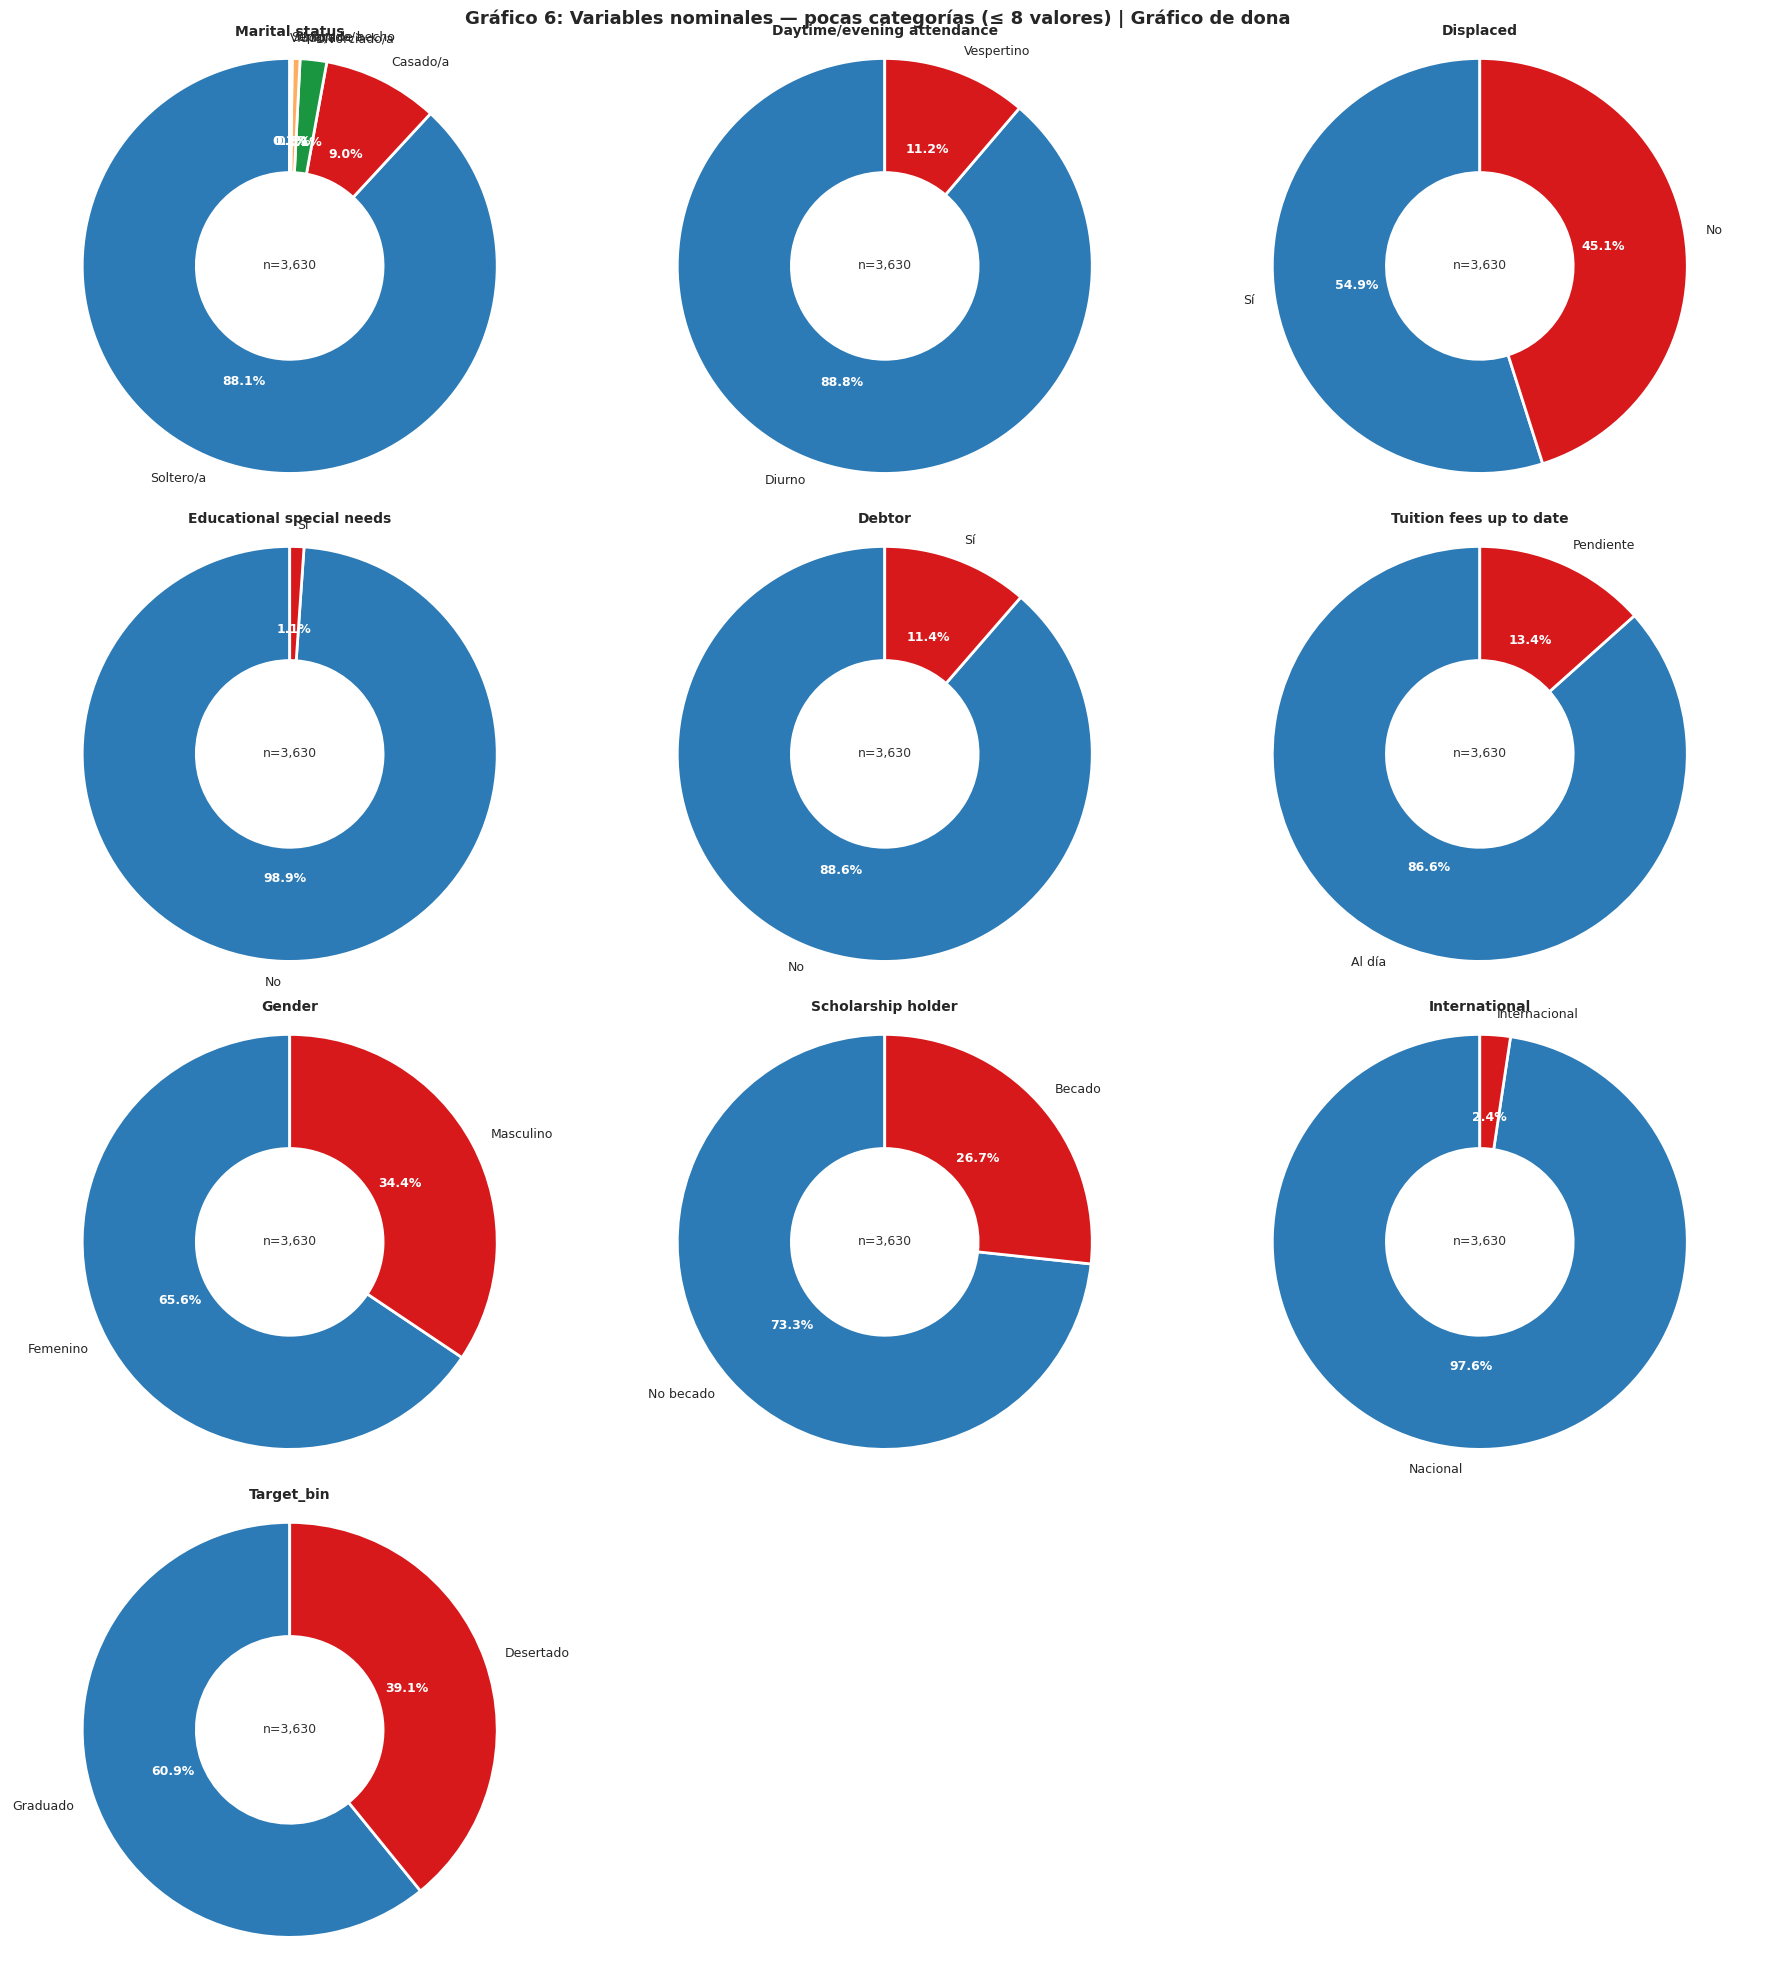

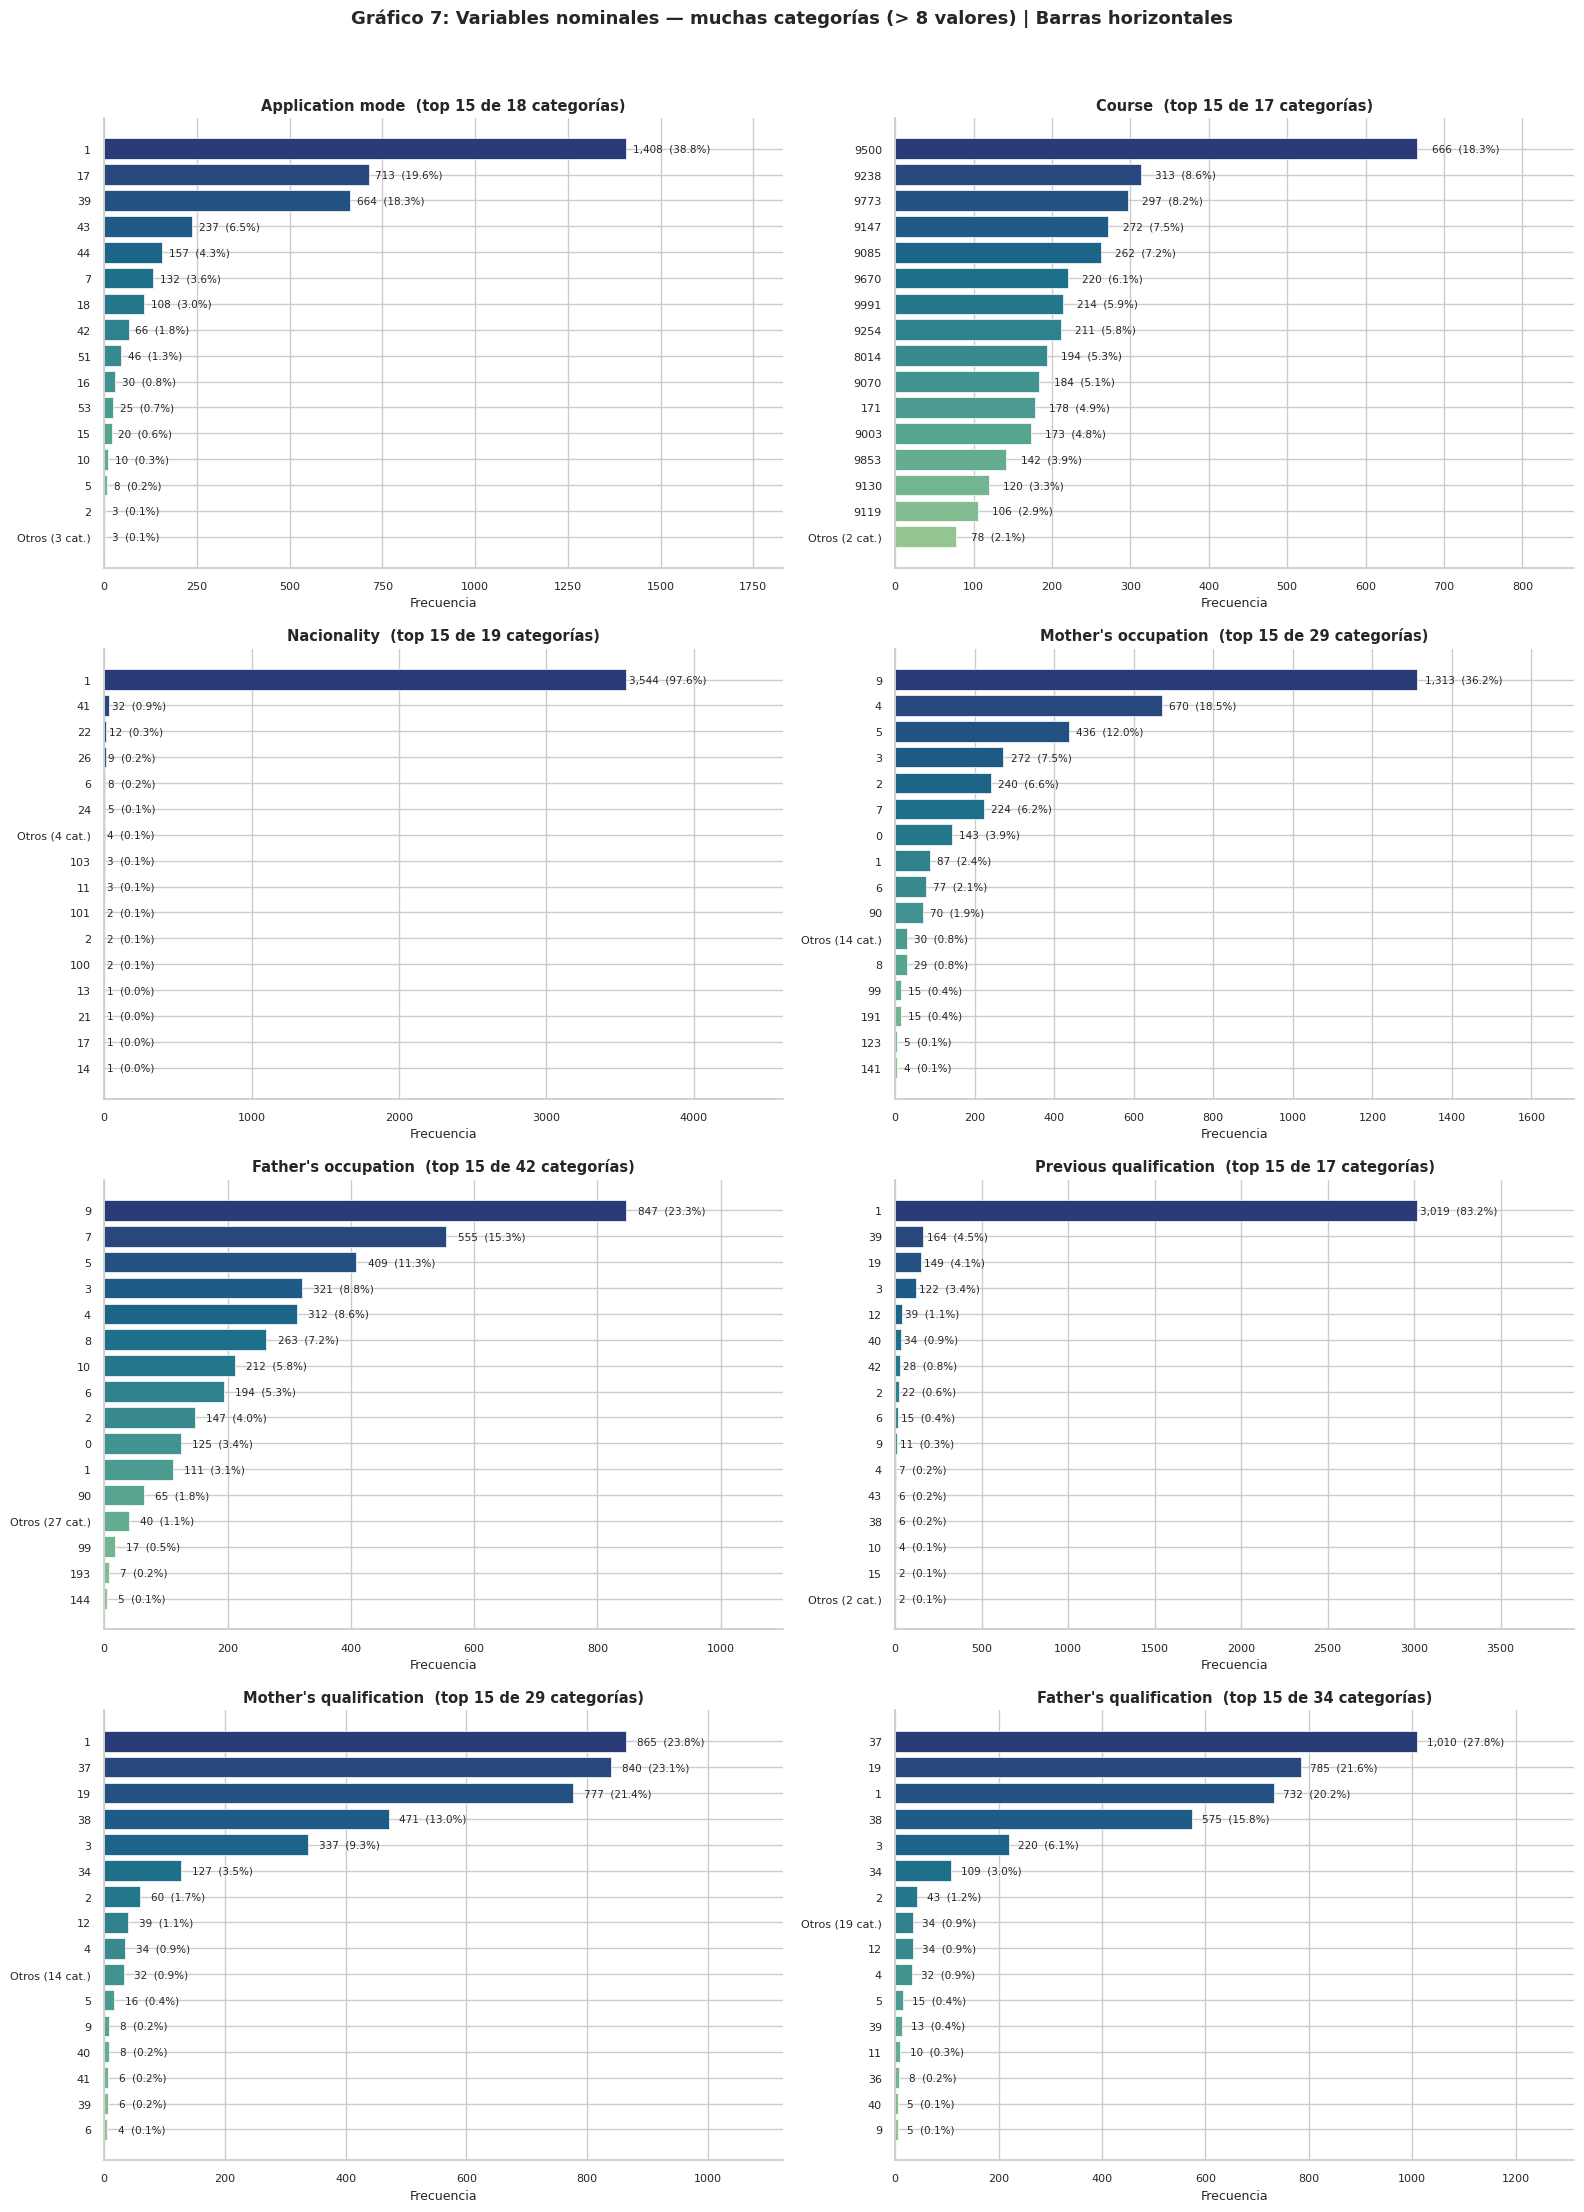

In [51]:
# ============================================================
# VISUALIZACIÓN — NOMINALES 
# Variables con <= 8 categorías únicas → gráfico de dona
# Variables con  > 8 categorías únicas → barras horizontales
# Etiquetas descriptivas en variables codificadas 0/1
# ============================================================
import numpy as np

# Mapa de etiquetas legibles (fuente: tabla de variables del dataset)
ETIQUETAS = {
    'Daytime/evening attendance': {1: 'Diurno', 0: 'Vespertino'},
    'Displaced':                  {1: 'Sí', 0: 'No'},
    'Educational special needs':  {1: 'Sí', 0: 'No'},
    'Debtor':                     {1: 'Sí', 0: 'No'},
    'Tuition fees up to date':    {1: 'Al día', 0: 'Pendiente'},
    'Gender':                     {1: 'Masculino', 0: 'Femenino'},
    'Scholarship holder':         {1: 'Becado', 0: 'No becado'},
    'International':              {1: 'Internacional', 0: 'Nacional'},
    'Target_bin':              {1: 'Graduado', 0: 'Desertado'},
    'Marital status':             {1: 'Soltero/a', 2: 'Casado/a',
                                    3: 'Viudo/a', 4: 'Divorciado/a',
                                    5: 'Unión de hecho', 6: 'Separado/a'},
}

def etiqueta(col, val):
    """Devuelve la etiqueta descriptiva de un valor, o el valor original."""
    mapa = ETIQUETAS.get(col, {})
    try:
        return mapa.get(int(val), str(val))
    except (TypeError, ValueError):
        return mapa.get(val, str(val))

UMBRAL_PIE = 8
PAL_PIE = ['#2C7BB6','#D7191C','#1A9641','#FDAE61',
           '#ABD9E9','#756BB1','#E6550D','#74C476']

vars_pie  = [c for c in vars_nominales if df_binario[c].nunique() <= UMBRAL_PIE]
vars_barh = [c for c in vars_nominales if df_binario[c].nunique() >  UMBRAL_PIE]

# ── Panel A: Donuts ──────────────────────────────────────────
n_cols_a = 3
n_rows_a = math.ceil(len(vars_pie) / n_cols_a)

fig_a, axs_a = plt.subplots(n_rows_a, n_cols_a,
                             figsize=(6 * n_cols_a, 5 * n_rows_a))
axs_a = np.array(axs_a).flatten()

for i, col in enumerate(vars_pie):
    conteo  = df_binario[col].value_counts()
    etiquetas_col = [etiqueta(col, v) for v in conteo.index]
    colores = PAL_PIE[:len(conteo)]

    wedges, texts, autotexts = axs_a[i].pie(
        conteo,
        labels=etiquetas_col,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2},
        colors=colores,
        textprops={'fontsize': 9}
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_fontweight('bold')
        at.set_color('white')

    axs_a[i].text(0, 0, f'n={conteo.sum():,}',
                  ha='center', va='center', fontsize=9, color='#333333')
    axs_a[i].set_title(col, fontsize=10, fontweight='bold', pad=6)
    axs_a[i].axis('equal')

for j in range(len(vars_pie), len(axs_a)):
    axs_a[j].axis('off')

fig_a.suptitle(
    'Gráfico 6: Variables nominales — pocas categorías (≤ 8 valores) | Gráfico de dona',
    fontsize=13, fontweight='bold'
)
plt.tight_layout(); plt.show()

# ── Panel B: Barras horizontales (matplotlib, sin warning) ──
n_cols_b = 2
n_rows_b = math.ceil(len(vars_barh) / n_cols_b)

fig_b, axs_b = plt.subplots(n_rows_b, n_cols_b,
                             figsize=(16, 5.5 * n_rows_b))
axs_b = np.array(axs_b).flatten()

TOP_N = 15   # variables con muchas categorías: mostrar las 15 más frecuentes

for i, col in enumerate(vars_barh):
    ax       = axs_b[i]
    conteo_c = df_binario[col].value_counts()
    total    = conteo_c.sum()
    n_cat    = len(conteo_c)

    # Si hay más de TOP_N categorías, mostrar las top y agrupar el resto en "Otros"
    if n_cat > TOP_N:
        top    = conteo_c.head(TOP_N)
        otros  = conteo_c.iloc[TOP_N:].sum()
        conteo = pd.concat([top, pd.Series({f'Otros ({n_cat - TOP_N} cat.)': otros})])
        conteo = conteo.sort_values(ascending=True)
        titulo = f'{col}  (top {TOP_N} de {n_cat} categorías)'
    else:
        conteo = conteo_c.sort_values(ascending=True)
        titulo = col

    pal  = sns.color_palette('crest', len(conteo))
    bars = ax.barh(conteo.index.astype(str), conteo.values,
                   color=pal, edgecolor='white', linewidth=0.5)

    for bar in bars:
        w = bar.get_width()
        ax.text(w + total * 0.005, bar.get_y() + bar.get_height() / 2,
                f'{int(w):,}  ({w/total*100:.1f}%)',
                va='center', ha='left', fontsize=7.5)

    ax.set_title(titulo, fontsize=10.5, fontweight='bold')
    ax.set_xlabel('Frecuencia', fontsize=9)
    ax.set_xlim(0, conteo.max() * 1.30)
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for j in range(len(vars_barh), len(axs_b)):
    axs_b[j].axis('off')

fig_b.suptitle(
    'Gráfico 7: Variables nominales — muchas categorías (> 8 valores) | Barras horizontales',
    fontsize=13, fontweight='bold', y=1.005
)
plt.tight_layout(rect=[0, 0, 1, 0.99]); plt.show()


#### Interpretación — Variables cualitativas nominales

- **`Target_bin`**: en el dataset binario (Graduate + Dropout), el 60,9 % de los estudiantes logró graduarse y el 39,1 % desertó. Esta distribución muestra un desbalance moderado (razón 1,55:1) que no exige tratamiento especial en esta fase, aunque deberá considerarse en la etapa de modelamiento predictivo.

- **`Tuition fees up to date`**: el 86,6 % de los estudiantes tiene los aranceles al día. La diferencia entre grupos es marcada: entre los Graduate el 98,7 % está al día, frente al 67,8 % en Dropout. Esta brecha de 31 puntos porcentuales es la más alta de todas las variables financieras y anticipa una asociación significativa con el resultado académico, que se contrasta formalmente en la sección 4.3.

- **`Scholarship holder`**: el 26,7 % de los estudiantes es becario. La proporción difiere sustancialmente entre grupos: 37,8 % en Graduate vs 9,4 % en Dropout. El apoyo económico mediante beca aparece como un factor protector relevante contra la deserción.

- **`Debtor`**: solo el 11,4 % de los estudiantes registra deuda institucional, pero la distribución por grupo es asimétrica: 4,6 % en Graduate vs 22,0 % en Dropout. Los estudiantes con deuda acumulan casi cinco veces más deserción que los no deudores, lo que refuerza la dimensión financiera del abandono.

- **`Gender`**: el 65,6 % de los estudiantes es femenino (código 0) y el 34,4 % masculino (código 1). La composición por grupo muestra diferencias relevantes: el 49,3 % del grupo Dropout es masculino frente al 24,8 % en Graduate, lo que sugiere mayor riesgo de deserción en hombres dentro de esta institución.

- **`Displaced`**, **`International`**, **`Educational special needs`**: las tres presentan alta concentración en una categoría. Los estudiantes desplazados (54,9 % del total) muestran diferencia moderada entre grupos (59,9 % Graduate vs 47,1 % Dropout). Los estudiantes internacionales (2,4 %) y con necesidades educativas especiales (1,1 %) son grupos muy minoritarios, lo que limita la potencia estadística de cualquier prueba específica para ellos.

- **`Previous qualification`** (reclasificada a nominal): la categoría modal es educación secundaria (código 1), que concentra el 83,2 % de los estudiantes, confirmando que la institución recibe predominantemente egresados de enseñanza media. Los cinco códigos más frecuentes concentran más del 96 % de los casos. Como los códigos no forman una escala ordenada monótona, se reporta moda y frecuencias, no mediana.

- **`Mother's qualification` y `Father's qualification`** (reclasificadas a nominal): presentan 29 y 34 categorías distintas respectivamente, con alta dispersión y concentración en niveles de escolaridad básica y secundaria. El código 34 ("Unknown") aparece con frecuencia apreciable en ambas, lo que confirma que tratarlas como ordinales sería metodológicamente incorrecto. Reflejan el perfil socioeconómico del estudiantado: en gran parte, primera generación con acceso a educación superior.

> **Relación con el problema:** las variables financieras (`Tuition fees up to date`, `Debtor`, `Scholarship holder`) muestran ya en la descripción distribuciones asimétricas entre Graduate y Dropout. Estas son candidatas directas para la prueba chi-cuadrado en la sección 4.3, dado que son nominales y no admiten prueba *t*. Las variables de calificación reclasificadas (`Previous qualification`, `Mother's/Father's qualification`) también podrían contrastarse con chi-cuadrado en análisis futuros.

---

<a id='2.10-bivariado'></a>
### 2.10 Análisis bivariado y correlaciones

Se examinan las relaciones entre pares de variables para identificar asociaciones relevantes al problema de deserción. El análisis se organiza en tres componentes: (1) matriz de correlación de Pearson entre variables numéricas, (2) distribución de variables clave según el resultado académico, y (3) tablas de contingencia entre variables financieras y `Target`.

---

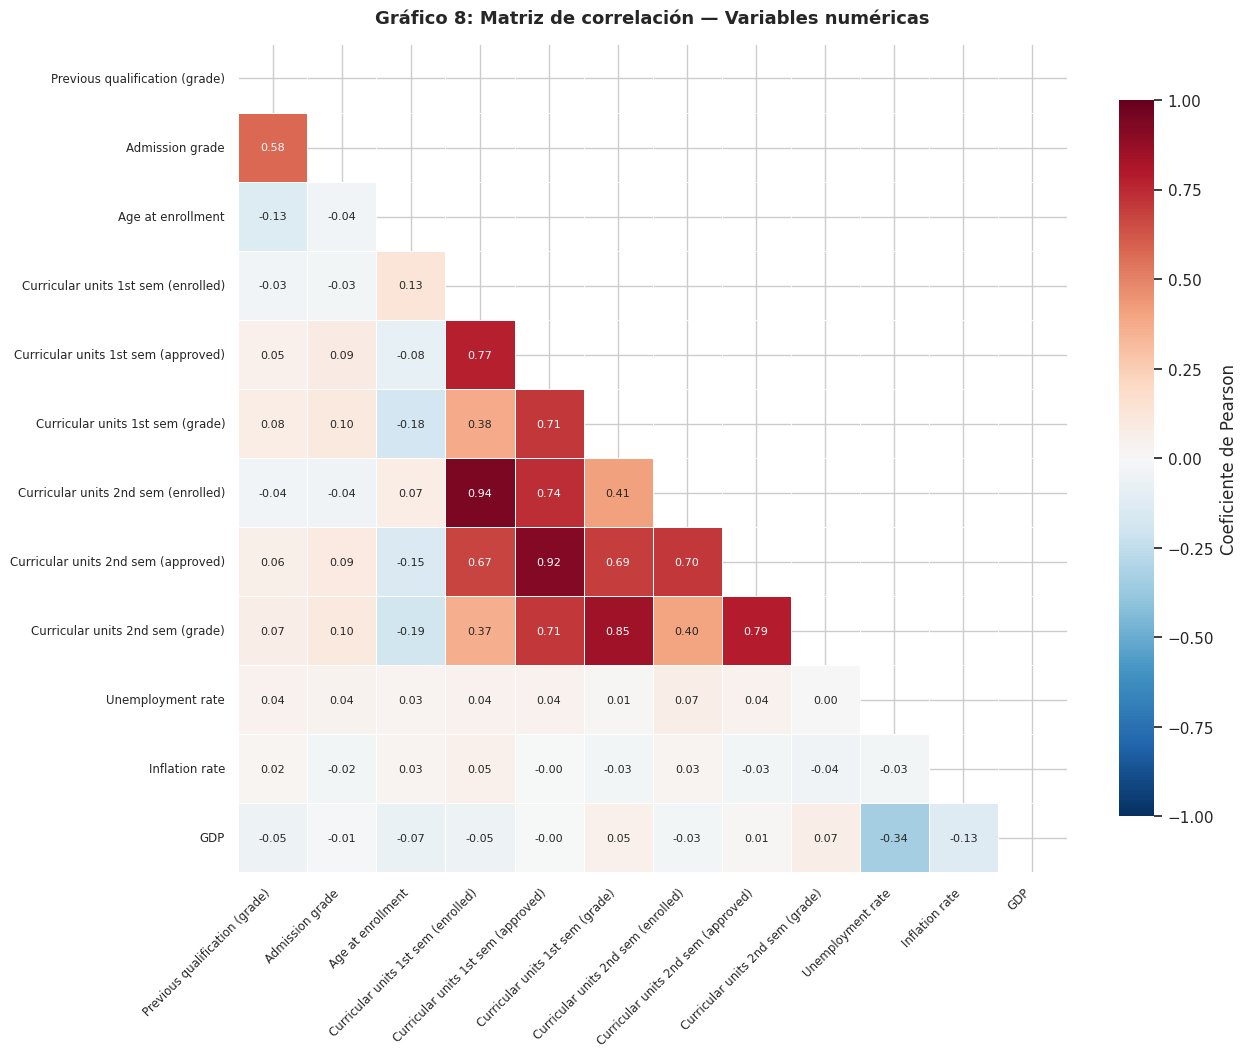

=== Top 10 correlaciones (por magnitud) ===


,Variable 1,Variable 2,Correlación
0,Curricular units 2nd sem (enrolled),Curricular units 1st sem (enrolled),0.9410
1,Curricular units 2nd sem (approved),Curricular units 1st sem (approved),0.9160
2,Curricular units 2nd sem (grade),Curricular units 1st sem (grade),0.8460
3,Curricular units 2nd sem (grade),Curricular units 2nd sem (approved),0.7870
4,Curricular units 1st sem (approved),Curricular units 1st sem (enrolled),0.7740
5,Curricular units 2nd sem (enrolled),Curricular units 1st sem (approved),0.7370
6,Curricular units 1st sem (grade),Curricular units 1st sem (approved),0.7100
7,Curricular units 2nd sem (grade),Curricular units 1st sem (approved),0.7090
8,Curricular units 2nd sem (approved),Curricular units 2nd sem (enrolled),0.7040
9,Curricular units 2nd sem (approved),Curricular units 1st sem (grade),0.6920


In [52]:
# ============================================================
# ANÁLISIS BIVARIADO 1 — MATRIZ DE CORRELACIÓN DE PEARSON
# Variables numéricas con interpretación estadística válida
# ============================================================

vars_num_corr = [
    'Previous qualification (grade)', 'Admission grade', 'Age at enrollment',
    'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

corr = df_binario[vars_num_corr].astype(float).corr(method='pearson')

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))   # ocultar triángulo superior

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Coeficiente de Pearson"},
    annot_kws={"size": 8}, ax=ax
)
ax.set_title("Gráfico 8: Matriz de correlación — Variables numéricas",
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8.5)
plt.yticks(rotation=0, fontsize=8.5)
plt.tight_layout()
plt.show()

# Top correlaciones (en valor absoluto) para facilitar la interpretación
corr_pairs = corr.where(~mask).stack().reset_index()
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlación']
corr_pairs['|r|'] = corr_pairs['Correlación'].abs()
top_corr = corr_pairs.sort_values('|r|', ascending=False).head(10).reset_index(drop=True)
print("=== Top 10 correlaciones (por magnitud) ===")
top_corr[['Variable 1', 'Variable 2', 'Correlación']].round(3)

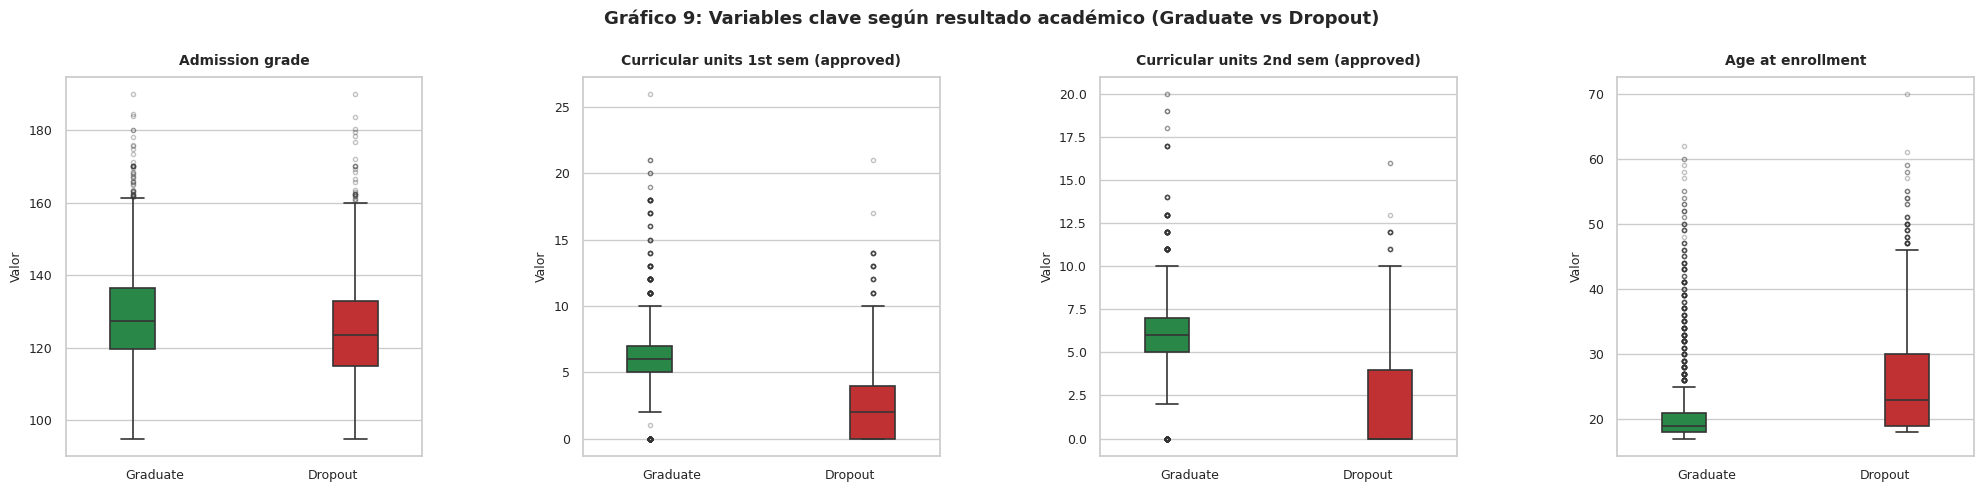

In [55]:
# ============================================================
# ANÁLISIS BIVARIADO 2 — VARIABLES CLAVE SEGÚN RESULTADO ACADÉMICO
# Boxplots de las variables más discriminantes
# Problema binario: Graduate vs Dropout
# ============================================================

# Preparar datos para gráficos
df_plot = df_binario.copy()
df_plot["Target"] = (
    df_plot["Target"]
    .astype("category")
    .cat.remove_unused_categories()
)

ORDEN_TARGET = ["Graduate", "Dropout"]

PAL_TARGET = {
    "Graduate": "#1A9641",
    "Dropout": "#D7191C"
}

vars_clave = [
    "Admission grade",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)",
    "Age at enrollment",
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, col in zip(axes, vars_clave):

    sns.boxplot(
        data=df_plot,
        x="Target",
        y=col,
        order=ORDEN_TARGET,
        hue="Target",
        hue_order=ORDEN_TARGET,
        palette=PAL_TARGET,
        legend=False,
        width=0.5,
        linewidth=1.2,
        flierprops=dict(
            marker="o",
            markersize=3,
            alpha=0.3
        ),
        ax=ax
    )

    ax.set_title(col, fontsize=10, fontweight="bold", pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("Valor", fontsize=9)
    ax.tick_params(labelsize=9)

fig.suptitle(
    "Gráfico 9: Variables clave según resultado académico (Graduate vs Dropout)",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.subplots_adjust(wspace=0.45)
plt.show()

In [22]:
# ============================================================
# ANÁLISIS BIVARIADO 3 — TABLAS DE CONTINGENCIA (% por grupo)
# Variables financieras vs Target
# ============================================================

ETIQUETAS_BIV = {
    'Scholarship holder':      {1: 'Becado', 0: 'No becado'},
    'Debtor':                  {1: 'Deudor', 0: 'No deudor'},
    'Tuition fees up to date': {1: 'Al día', 0: 'Pendiente'},
}

for cat in ['Scholarship holder', 'Debtor', 'Tuition fees up to date']:
    ct = pd.crosstab(df_binario[cat], df_binario['Target'], normalize='columns') * 100
    ct.index = [ETIQUETAS_BIV[cat].get(i, i) for i in ct.index]
    print(f"=== % de '{cat}' dentro de cada grupo Target ===")
    print(ct.round(1).to_string())
    print()

=== % de 'Scholarship holder' dentro de cada grupo Target ===
Target     Dropout  Graduate
No becado  90.6000   62.2000
Becado      9.4000   37.8000

=== % de 'Debtor' dentro de cada grupo Target ===
Target     Dropout  Graduate
No deudor  78.0000   95.4000
Deudor     22.0000    4.6000

=== % de 'Tuition fees up to date' dentro de cada grupo Target ===
Target     Dropout  Graduate
Pendiente  32.2000    1.3000
Al día     67.8000   98.7000



#### Interpretación — Análisis bivariado

**Correlaciones entre variables numéricas (Pearson):**
Las correlaciones más altas del dataset se observan dentro del bloque de rendimiento académico. Las unidades inscritas de primer y segundo semestre muestran la correlación más elevada (r = 0,941), indicando que los estudiantes mantienen una carga académica muy consistente entre semestres. Las unidades aprobadas entre semestres también presentan correlación muy alta (r = 0,916), y las notas entre semestres correlacionan fuertemente (r = 0,846): quien rinde bien en el primer semestre tiende a mantener ese desempeño en el segundo, y viceversa. La edad al ingreso presenta correlación negativa débil con las notas semestrales (r = −0,18 y −0,19), sugiriendo que estudiantes de mayor edad obtienen calificaciones levemente menores en promedio. Las variables macroeconómicas (desempleo, inflación, PIB) muestran correlaciones prácticamente nulas con el rendimiento individual (|r| < 0,06 en todos los casos), confirmando que el contexto económico es una variable de entorno sin capacidad predictiva directa sobre el desempeño académico.

**Distribución por resultado académico (boxplots):**
Los boxplots confirman visualmente que los cursos aprobados en ambos semestres son las variables que más separan a los grupos: los Graduate concentran sus distribuciones en valores altos (mediana = 6 en ambos semestres) mientras los Dropout se agrupan cerca de cero (mediana = 2 en primer semestre y 0 en segundo). La nota de admisión también difiere entre grupos, aunque con mayor solapamiento (Graduate: 128,8 vs Dropout: 125,0). La edad al ingreso es mayor en promedio en los Dropout (26,1 vs 21,8 años), con mayor dispersión.

**Variables financieras (tablas de contingencia):**
Las tablas de contingencia revelan asociaciones marcadas entre las variables financieras y el resultado académico. El 98,7 % de los Graduate tiene aranceles al día, frente al 67,8 % de los Dropout: una brecha de 31 puntos porcentuales. La condición de deudor es casi cinco veces más frecuente en Dropout (22,0 %) que en Graduate (4,6 %). La beca es más frecuente entre quienes se gradúan (37,8 %) que entre quienes desertan (9,4 %), lo que sugiere que el apoyo económico institucional actúa como factor protector. Estas asociaciones se contrastan formalmente mediante pruebas chi-cuadrado en la sección 4.3.

> **Relación con el problema:** el análisis bivariado refuerza la hipótesis central del proyecto: el rendimiento académico temprano (especialmente las unidades aprobadas en el primer semestre) y la situación financiera del estudiante (estado de pago de aranceles, deuda y beca) son los dos ejes que mejor diferencian a quienes se gradúan de quienes desertan. Esta evidencia descriptiva orienta la selección de variables para las pruebas de hipótesis y el modelamiento predictivo de etapas posteriores.

---

<a id='2.11-outliers'></a>
## 2.11 Detección de outliers

Aunque el dataset no presenta faltantes ni duplicados, la presencia de **valores atípicos**
puede distorsionar medias, varianzas y los supuestos de las pruebas paramétricas. Se aplica
el **método del rango intercuartílico (IQR)**: se consideran atípicos los valores fuera del
intervalo sobre las variables numéricas continuas y la edad.

$$[\,Q_1 - 1.5 \times IQR,\ \ Q_3 + 1.5 \times IQR\,]$$



In [23]:
# ============================================================
# 4.1 DETECCIÓN DE OUTLIERS (MÉTODO IQR)
# ============================================================
vars_outlier = [
  'Previous qualification (grade)', 'Admission grade',
  'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
  'Curricular units 1st sem (enrolled)', 'Curricular units 2nd sem (enrolled)',
  'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)',
  'Age at enrollment', 'Unemployment rate', 'Inflation rate', 'GDP'
]

filas = []
outlier_idx = {}
for col in vars_outlier:
    q1, q3 = df_binario[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df_binario[col] < li) | (df_binario[col] > ls)
    outlier_idx[col] = df_binario.index[mask]
    filas.append({
        "Variable": col, "Q1": round(q1, 2), "Q3": round(q3, 2),
        "IQR": round(iqr, 2), "Lím. inf.": round(li, 2), "Lím. sup.": round(ls, 2),
        "N outliers": int(mask.sum()), "% outliers": round(mask.mean() * 100, 1),
    })

tabla_out = pd.DataFrame(filas)
print("=== Detección de outliers (método IQR) ===")
print(tabla_out.to_string(index=False))

=== Detección de outliers (método IQR) ===
                           Variable       Q1       Q3     IQR  Lím. inf.  Lím. sup.  N outliers  % outliers
     Previous qualification (grade) 125.0000 140.0000 15.0000   102.5000   162.5000         146      4.0000
                    Admission grade 118.0000 135.1000 17.1000    92.3500   160.7500          71      2.0000
   Curricular units 1st sem (grade)  11.0000  13.5000  2.5000     7.2500    17.2500         652     18.0000
   Curricular units 2nd sem (grade)  10.5200  13.5000  2.9800     6.0400    17.9700         803     22.1000
Curricular units 1st sem (enrolled)   5.0000   7.0000  2.0000     2.0000    10.0000         366     10.1000
Curricular units 2nd sem (enrolled)   5.0000   7.0000  2.0000     2.0000    10.0000         321      8.8000
Curricular units 1st sem (approved)   3.0000   6.0000  3.0000    -1.5000    10.5000         165      4.5000
Curricular units 2nd sem (approved)   2.0000   6.0000  4.0000    -4.0000    12.0000          

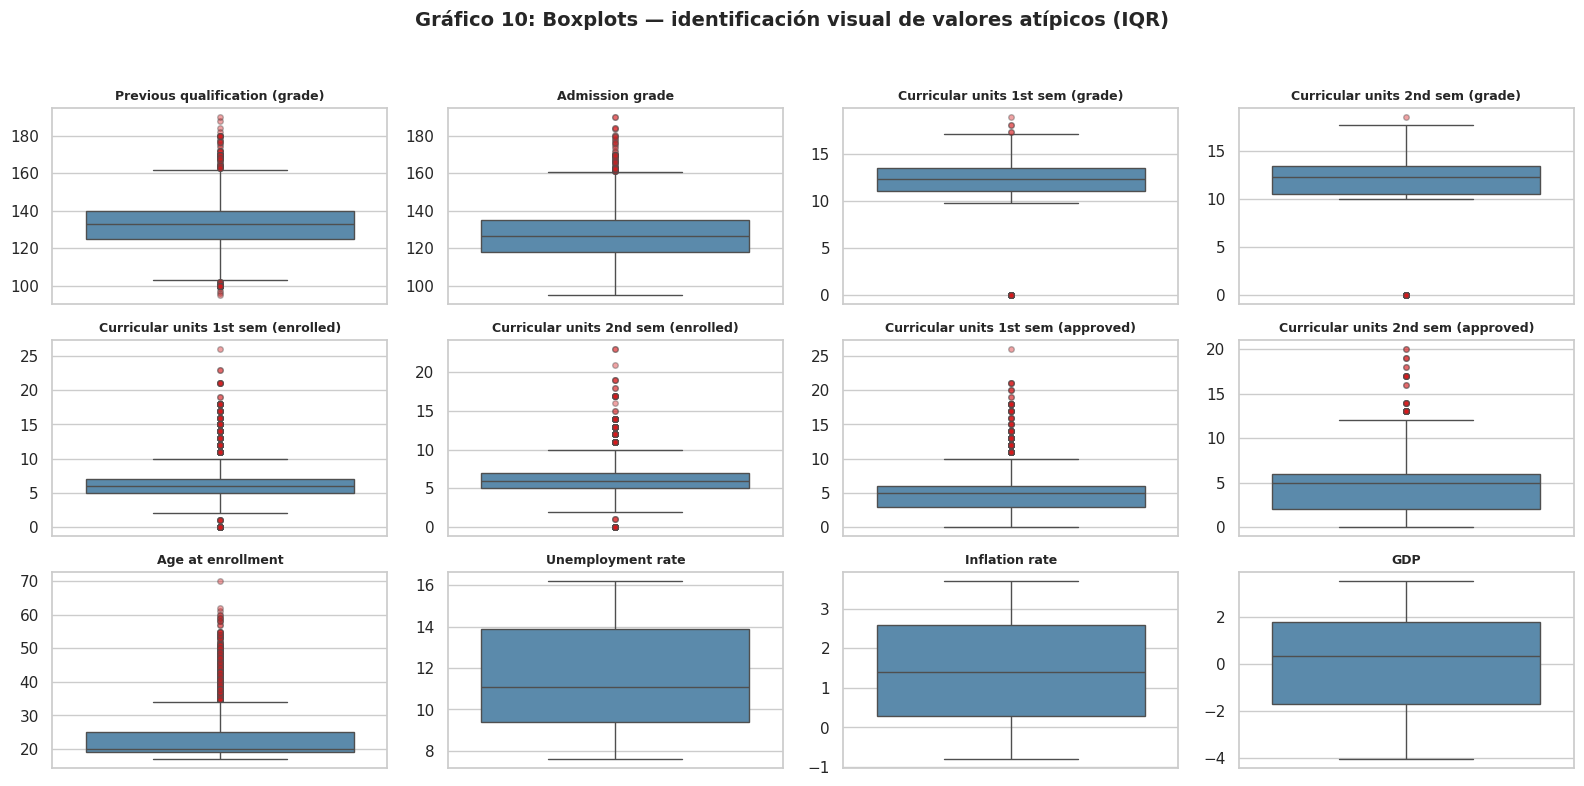

In [57]:
# ============================================================
# VISUALIZACIÓN — BOXPLOTS DE VARIABLES CON OUTLIERS
# ============================================================
fig, axes = plt.subplots(3, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(vars_outlier):
    sns.boxplot(y=df_binario[col], ax=axes[i], color="#4E8CB8",
                flierprops=dict(marker="o", markerfacecolor='#D7191C',
                                markersize=4, alpha=0.4))
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].set_ylabel("")
plt.suptitle("Gráfico 10: Boxplots — identificación visual de valores atípicos (IQR)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Decisión sobre el tratamiento de outliers

El método IQR se aplicó a las 12 variables cuantitativas del análisis. La decisión tambien se base tomando en consideranción las variables con mayor porcentaje de outliers. Se identificaron tres patrones, todos con justificación para conservar los registros:

**Notas semestrales y edad:** el 100% de los outliers bajos en `Curricular units (grade)` son calificaciones de 0, y el 88–91% pertenece a Dropout (vs 39% en la distribución general). Son la señal de abandono, no ruido. Eliminarlos descartaría entre el 40–51% del grupo Dropout. Las edades altas también sobrerrepresentan Dropout (61%), consistente con estudiantes adultos de mayor vulnerabilidad académica.

**Unidades aprobadas (`approved`):** outliers de valores altos (4,1% y 1,0%), dominados por Graduate (81–93%). Corresponden a trayectorias académicas atípicamente exitosas, posiblemente con créditos convalidados. No son errores de medición.

**Unidades inscritas (`enrolled`):** outliers de valores altos (9,6% y 8,3%), con composición Graduate/Dropout (62%/38%) casi idéntica a la distribución general del dataset. Variabilidad normal en carga inscrita, sin asociación con el resultado académico.

**Variables macroeconómicas (`Unemployment rate`, `Inflation rate`, `GDP`):** sin outliers por IQR.

En consecuencia, se conservan todos los registros. Con n > 1.400 por grupo, el TLC  garantiza la validez de la prueba *t* independientemente de la forma de los datos originales. La relevancia práctica de estas decisiones se confirma en la sección 4.2 con el cálculo del tamaño del efecto (Cohen's *d*).

<a id='3-ic'></a>
## 3. Estimación puntual e intervalos de confianza

Se seleccionaron **10 variables numéricas** agrupadas en tres dimensiones: Perfil de ingreso · Rendimiento semestral · Contexto macroeconómico. Los IC son **estadísticamente válidos** dado que el dataset se trata como muestra de la población de futuros estudiantes (Realinho et al., 2022).

---

In [25]:
# ============================================================
# ESTIMACIÓN PUNTUAL E INTERVALOS DE CONFIANZA AL 95%
# t de Student | pandas ddof=1 (MUESTRA)
# ============================================================

vars_ic = [
    'Previous qualification (grade)', 'Admission grade', 'Age at enrollment',
    'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

DIMENSIONES_IC = {
    'Previous qualification (grade)':     'Perfil de ingreso',
    'Admission grade':                     'Perfil de ingreso',
    'Age at enrollment':                   'Perfil de ingreso',
    'Curricular units 1st sem (approved)': 'Rendimiento semestral',
    'Curricular units 1st sem (grade)':    'Rendimiento semestral',
    'Curricular units 2nd sem (approved)': 'Rendimiento semestral',
    'Curricular units 2nd sem (grade)':    'Rendimiento semestral',
    'Unemployment rate':                   'Contexto macroeconómico',
    'Inflation rate':                      'Contexto macroeconómico',
    'GDP':                                 'Contexto macroeconómico',
}

resultados_ic = []
for col in vars_ic:
    datos     = df_binario[col].dropna().astype(float)
    n         = len(datos)
    media     = float(datos.mean())
    error_std = stats.sem(datos)          # std/sqrt(n), scipy
    ic        = stats.t.interval(0.95, df=n-1, loc=media, scale=error_std)
    resultados_ic.append({
        'Variable':        col,
        'Dimensión':       DIMENSIONES_IC[col],
        'N':               n,
        'NaN':             int(df_binario[col].isnull().sum()),
        'Media (μ)':       round(media, 4),
        's':               round(float(datos.std(ddof=1)), 4),      # pandas — MUESTRA
        'Error est.':      round(error_std, 4),
        'IC 95% inf.':     round(ic[0], 4),
        'IC 95% sup.':     round(ic[1], 4),
    })

ic_df = pd.DataFrame(resultados_ic)
print("=== IC al 95% | s muestral (pandas ddof=1) | t de Student ===")
ic_df

=== IC al 95% | s muestral (pandas ddof=1) | t de Student ===


,Variable,Dimensión,N,NaN,Media (μ),s,Error est.,IC 95% inf.,IC 95% sup.
0,Previous qualification (grade),Perfil de ingreso,3630,0,132.9206,13.2384,0.2197,132.4898,133.3514
1,Admission grade,Perfil de ingreso,3630,0,127.2939,14.6113,0.2425,126.8185,127.7694
2,Age at enrollment,Perfil de ingreso,3630,0,23.4612,7.8280,0.1299,23.2064,23.7159
3,Curricular units 1st sem (approved),Rendimiento semestral,3630,0,4.7915,3.2378,0.0537,4.6861,4.8968
4,Curricular units 1st sem (grade),Rendimiento semestral,3630,0,10.5349,5.0577,0.0839,10.3703,10.6994
5,Curricular units 2nd sem (approved),Rendimiento semestral,3630,0,4.5185,3.1624,0.0525,4.4155,4.6214
6,Curricular units 2nd sem (grade),Rendimiento semestral,3630,0,10.0362,5.4817,0.0910,9.8578,10.2145
7,Unemployment rate,Contexto macroeconómico,3630,0,11.6304,2.6677,0.0443,11.5435,11.7172
8,Inflation rate,Contexto macroeconómico,3630,0,1.2316,1.3849,0.0230,1.1865,1.2767
9,GDP,Contexto macroeconómico,3630,0,-0.0093,2.2600,0.0375,-0.0828,0.0643


**Complemento — proporción de desertores.** Además de las 10 medias anteriores, se
estima la **proporción poblacional de estudiantes que desertan** (`Target = Dropout`). Por
tratarse de una proporción, el intervalo de confianza se calcula con el **método de Wilson**
en lugar de la aproximación normal (Wald): Wilson es más preciso porque no asume que la
distribución muestral de *p̂* es exactamente normal, y se comporta mejor cuando *p* se aleja
de 0,5 o el tamaño muestral no es muy grande (Newcombe, 1998).

In [26]:
# ============================================================
# PROPORCIÓN DE DESERTORES — Intervalo de Wilson (no Wald)
# El método de Wilson es más preciso que la aproximación normal,
# especialmente cuando p se aleja de 0.5 o n no es muy grande.
# ============================================================
from statsmodels.stats.proportion import proportion_confint

n_total    = len(df_binario)
desertores = (df_binario['Target'] == 'Dropout').sum()
p_hat      = desertores / n_total

ic_lo, ic_hi = proportion_confint(desertores, n_total, alpha=0.05, method='wilson')

# Referencia: lo que arrojaría Wald (aproximación normal), solo para comparar
ic_lo_wald, ic_hi_wald = proportion_confint(desertores, n_total, alpha=0.05, method='normal')

prop_df = pd.DataFrame([{
    'Variable':        'Target',
    'Categoría':       'Dropout',
    'n':               n_total,
    'Desertores':      int(desertores),
    'Proporción':      round(p_hat, 4),
    'IC 95% inf. (Wilson)': round(ic_lo, 4),
    'IC 95% sup. (Wilson)': round(ic_hi, 4),
}])

print("=== Proporción de desertores — IC 95% (Wilson) ===")
print(f"n = {n_total} | Desertores = {desertores} | p̂ = {p_hat:.4%}")
print(f"IC 95% (Wilson) : [{ic_lo:.4%}, {ic_hi:.4%}]")
print(f"IC 95% (Wald, referencia) : [{ic_lo_wald:.4%}, {ic_hi_wald:.4%}]")
prop_df

=== Proporción de desertores — IC 95% (Wilson) ===
n = 3630 | Desertores = 1421 | p̂ = 39.1460%
IC 95% (Wilson) : [37.5705%, 40.7444%]
IC 95% (Wald, referencia) : [37.5583%, 40.7338%]


,Variable,Categoría,n,Desertores,Proporción,IC 95% inf. (Wilson),IC 95% sup. (Wilson)
0,Target,Dropout,3630,1421,0.3915,0.3757,0.4074


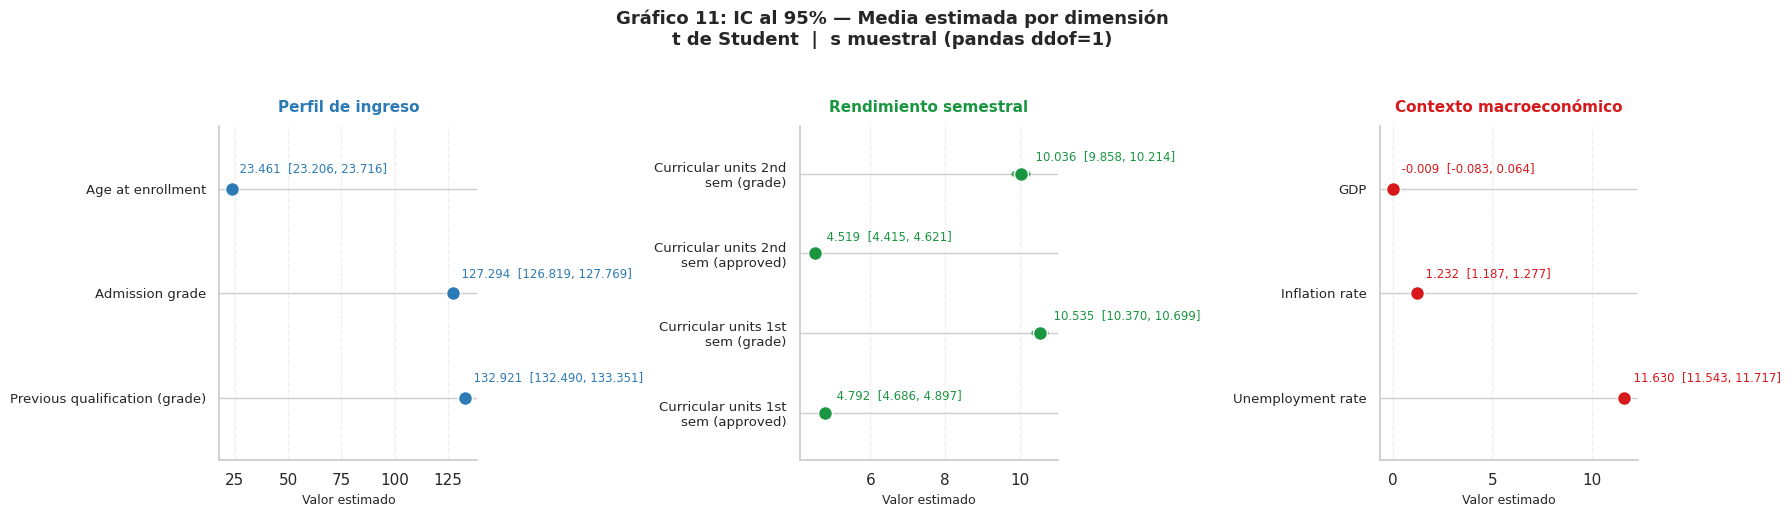

In [58]:
# Forest plot — un panel por dimensión con su propia escala
dims   = list(dict.fromkeys(DIMENSIONES_IC.values()))
COL_IC = {'Perfil de ingreso': '#2C7BB6',
           'Rendimiento semestral': '#1A9641',
           'Contexto macroeconómico': '#D7191C'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, dim in zip(axes, dims):
    sub   = ic_df[ic_df['Dimensión'] == dim].reset_index(drop=True)
    color = COL_IC[dim]
    for j, row in sub.iterrows():
        ax.plot([row['IC 95% inf.'], row['IC 95% sup.']], [j, j],
                color=color, lw=4, solid_capstyle='round', alpha=0.75)
        ax.scatter(row['Media (μ)'], j, color=color, zorder=5, s=100,
                   edgecolor='white', lw=1)
        ax.text(row['IC 95% sup.'], j+0.12,
                f"  {row['Media (μ)']:.3f}  [{row['IC 95% inf.']:.3f}, {row['IC 95% sup.']:.3f}]",
                va='bottom', ha='left', fontsize=8.5, color=color)
    labels = [v.replace(' sem ', '\nsem ') for v in sub['Variable']]
    ax.set_yticks(range(len(sub))); ax.set_yticklabels(labels, fontsize=9.5)
    ax.set_ylim(-0.6, len(sub)-0.4)
    ax.set_xlabel('Valor estimado', fontsize=9)
    ax.set_title(dim, fontsize=11, fontweight='bold', color=color, pad=10)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Gráfico 11: IC al 95% — Media estimada por dimensión\nt de Student  |  s muestral (pandas ddof=1)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

#### Interpretación — Intervalos de confianza al 95 %

Los intervalos de confianza permiten cuantificar la precisión de las estimaciones y delimitar el rango plausible de cada parámetro. Dado que la desviación estándar poblacional (σ) es desconocida, todos los IC de medias se construyeron con la **distribución *t* de Student** (`scipy.stats.t.interval`, `ddof=1`), que es la alternativa correcta cuando σ debe estimarse a partir de los datos. Para la proporción de desertores se utilizó el **método de Wilson** (`proportion_confint`, `method='wilson'`), más preciso que la aproximación normal cuando la proporción se aleja de 0,5.

**Perfil de ingreso:**
- La nota de calificación previa y la nota de admisión presentan **IC estrechos**, lo que refleja alta precisión en la estimación dado el tamaño de la muestra (n = 3.630). Las cotas inferior y superior están muy próximas a la media, indicando homogeneidad relativa en este parámetro.
- La edad al ingreso también muestra un IC estrecho, consistente con una muestra predominantemente joven y de ingreso directo desde la enseñanza media.

**Rendimiento semestral:**
- Las unidades aprobadas en ambos semestres presentan IC que no incluyen el cero, confirmando que el promedio muestral está en valores positivos. No obstante, la dispersión (*s*) es alta, coherente con las diferencias entre graduados y desertores observadas en los boxplots.
- Las notas promedio de primer y segundo semestre muestran IC por encima del valor de aprobación mínima (típicamente 10/20), lo que indica que la media muestral supera el umbral, aunque la distribución tiene una cola izquierda con estudiantes en riesgo.

**Contexto macroeconómico:**
- La tasa de desempleo y la inflación presentan IC más amplios, coherentes con la variabilidad entre cohortes de distintos años. El PIB presenta un IC que puede incluir valores negativos, consistente con períodos de recesión económica registrados durante el período de estudio (2008–2019).

**Proporción de desertores (método de Wilson):**
- La proporción muestral de estudiantes en estado *Dropout* dentro del dataset binario (Graduate + Dropout) es **39,15 %** (1.421/3.630), con IC 95 % (Wilson): **[37,57 % ; 40,74 %]**. La amplitud de 3,2 puntos porcentuales refleja una estimación razonablemente precisa dado el tamaño muestral. Bajo el razonamiento frecuentista correcto: si se repitiera el muestreo, alrededor del 95 % de los intervalos así construidos contendrían la verdadera proporción poblacional de desertores — no existe un 95 % de probabilidad de que el valor real esté en *este* intervalo específico. Se utilizó Wilson en lugar de Wald porque no requiere que *n·p̂·(1−p̂)* sea grande para mantener buena cobertura (Newcombe, 1998).

> **Nota metodológica:** los IC son válidos bajo el enfoque muestral adoptado — los 3.630 registros del dataset binario representan una muestra de la población de interés (futuros estudiantes de instituciones similares), tal como lo indica el uso de los datos para construir modelos predictivos generalizables (Realinho et al., 2022).

---

**Limitaciones de las estimaciones** *(en cumplimiento del indicador ID1.3):*
- Los IC asumen **muestreo aleatorio** de la población. El dataset es un registro institucional acotado a una sola institución portuguesa (2008–2019), por lo que la generalización a otras instituciones o períodos debe hacerse con cautela.
- La amplitud de cada IC depende del **error estándar**, que disminuye con el tamaño muestral. Con n = 3.630 los IC son estrechos, lo que refleja alta precisión estadística pero no corrige posibles **sesgos sistemáticos** del registro (p. ej., ausencia de cohortes de otras instituciones o años fuera del período de estudio).
- Para variables que funcionan como **códigos categóricos** (no incluidas aquí), la media y su IC carecerían de interpretación válida; por eso la estimación se restringe a variables con escala numérica genuina.
- El IC cuantifica incertidumbre **muestral**, no **incertidumbre del modelo** ni errores de medición en los datos originales.

<a id='4-hipotesis'></a>
## 4. Pruebas de hipótesis

---

<a id='4.1-supuestos'></a>
### 4.1 Verificación de supuestos

Antes de aplicar la prueba *t*, se verifican sus supuestos:

**1. Normalidad.** La prueba *t* asume que la distribución muestral de la media es aproximadamente normal. Dado que ambos grupos tienen tamaños muy superiores a 30 (Graduate ≈ 2.200, Dropout ≈ 1.440), el **Teorema del Límite Central** (F1-5) garantiza esta condición independientemente de la forma de los datos originales. 

> **Nota metodológica:** no se aplica la prueba de Shapiro-Wilk porque con muestras de este tamaño rechaza la normalidad ante desviaciones triviales sin consecuencia práctica, entregando un resultado engañoso. En su lugar se usan **Q-Q plots** como apoyo visual, válidos a cualquier tamaño muestral, y se invoca el TLC como sustento formal.

**2. Homogeneidad de varianzas.** Se contrasta con la **prueba de Levene**. Cuando las varianzas resultan distintas (p < 0,05), se emplea la **corrección de Welch** (`equal_var=False`), que no asume igualdad de varianzas y es la opción más robusta.

---

SUPUESTO 1 — NORMALIDAD (sustento por TLC)
n Graduate = 2,209   |   n Dropout = 1,421
Ambos n >> 30  →  el TLC garantiza normalidad de la media muestral.
Se usan Q-Q plots como apoyo visual (no Shapiro-Wilk).



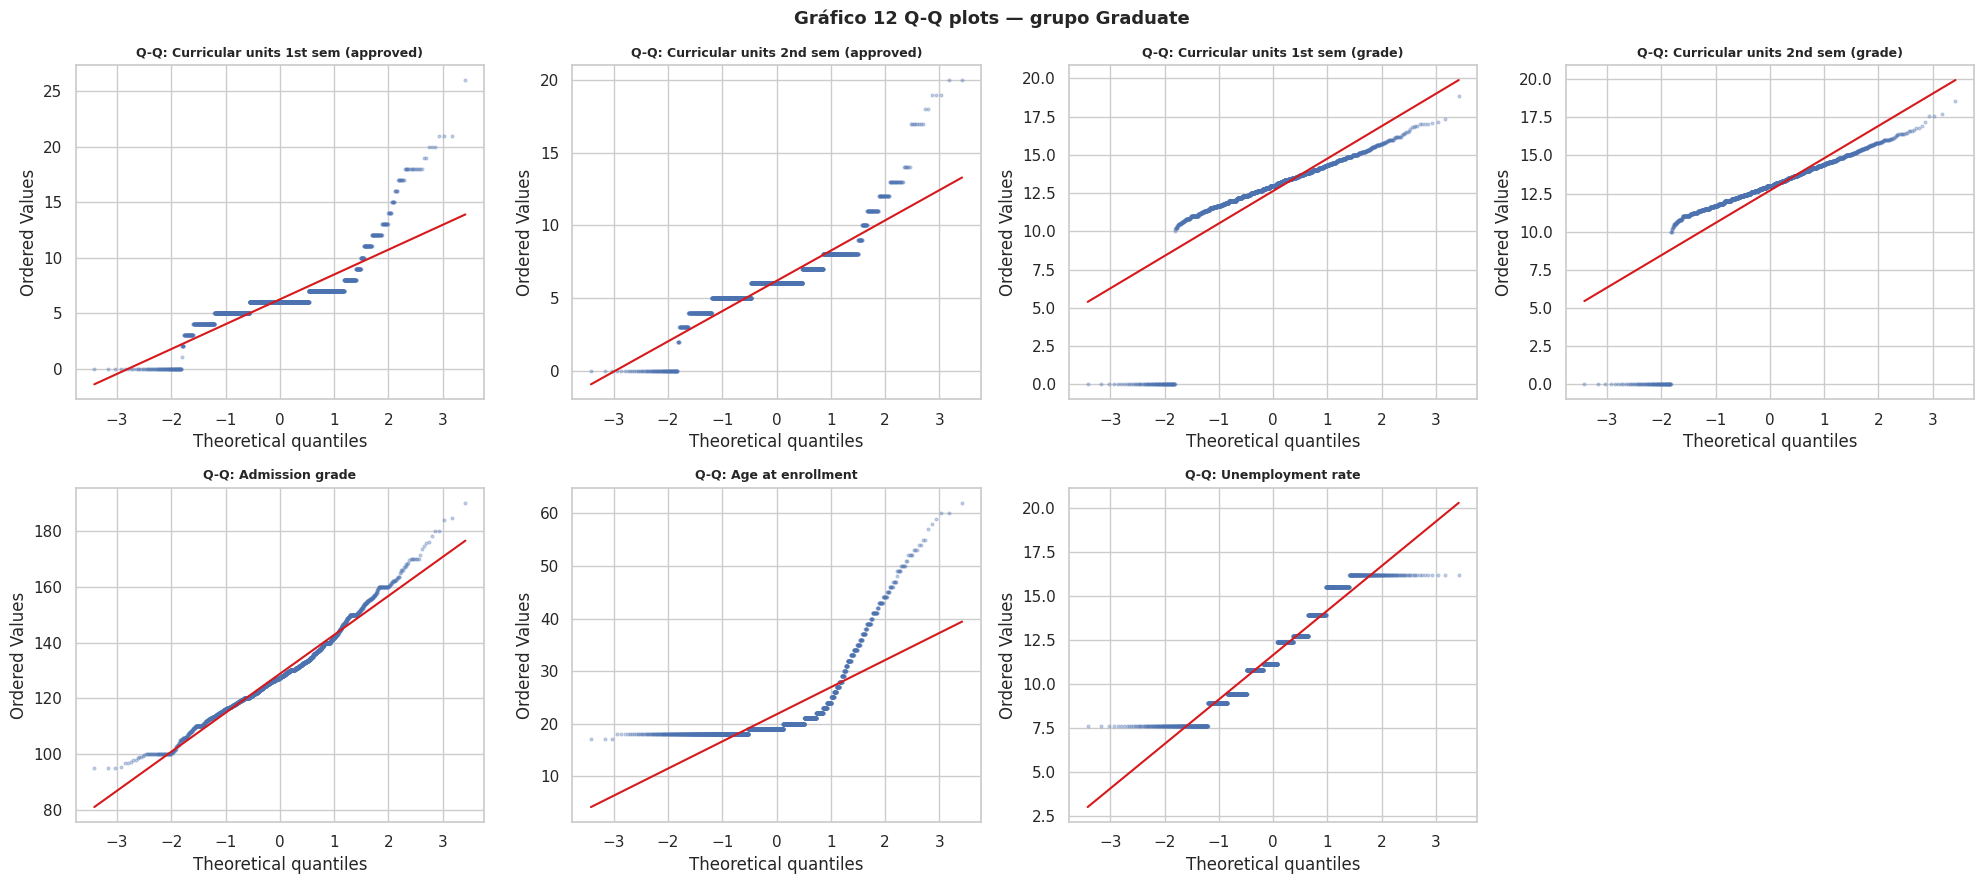

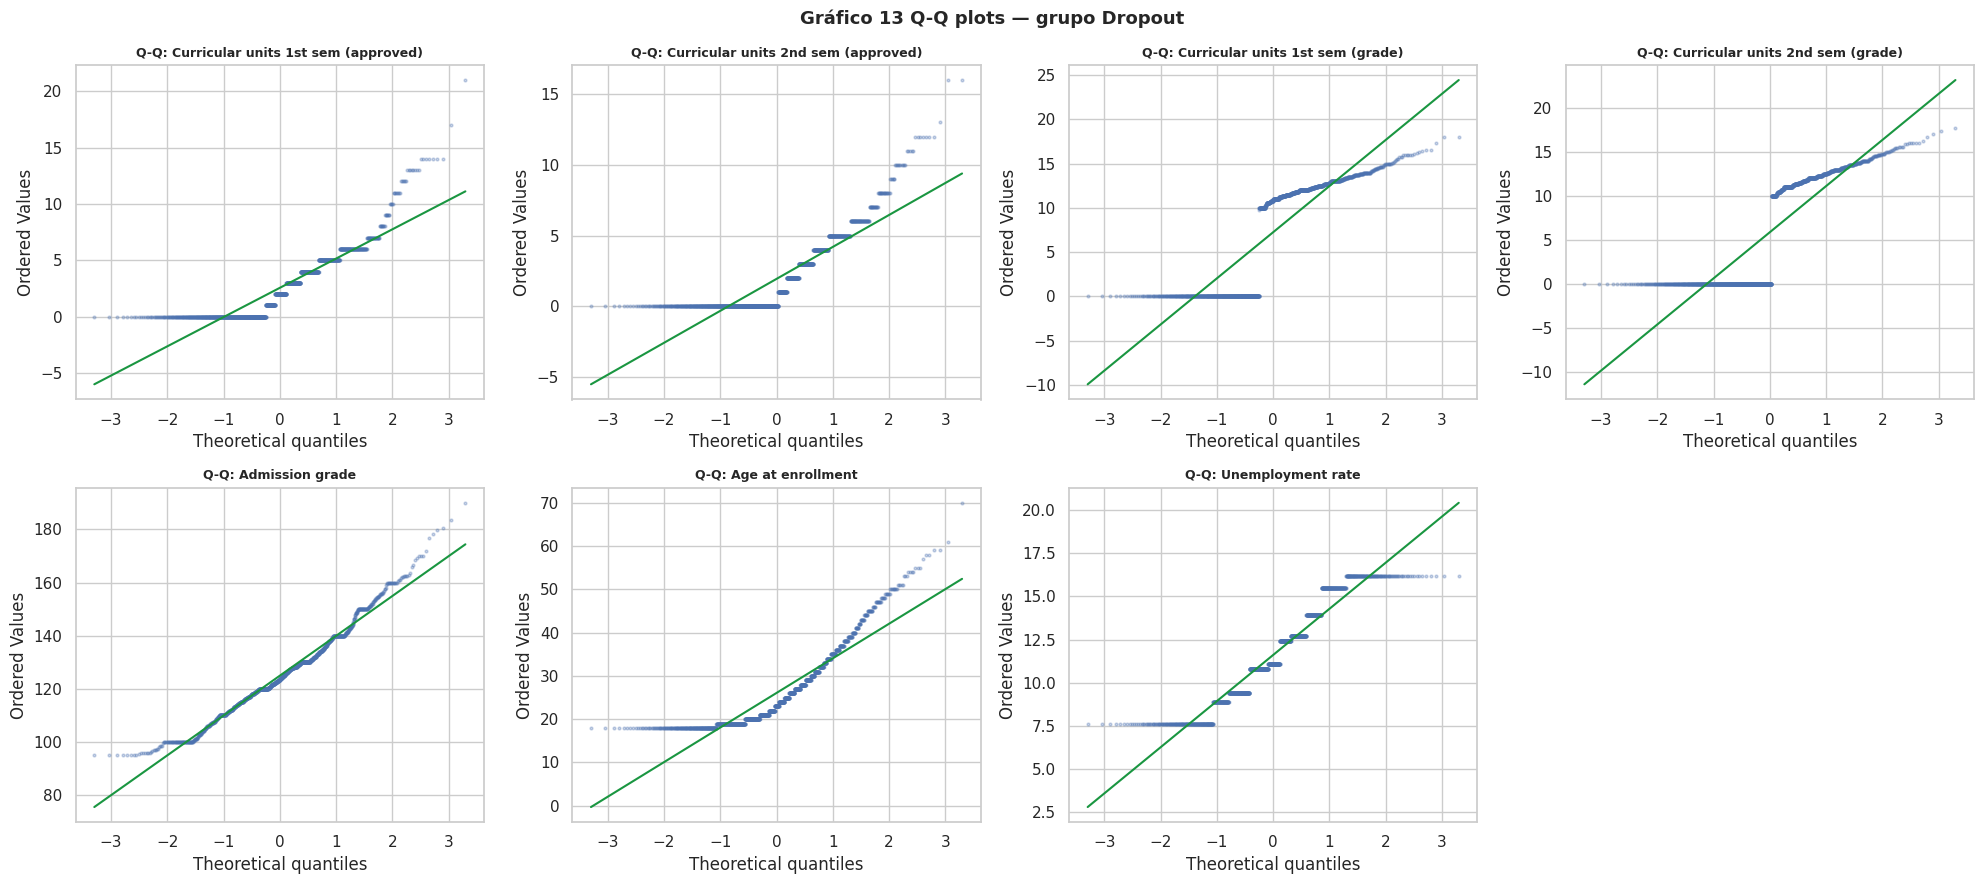

SUPUESTO 2 — HOMOGENEIDAD DE VARIANZAS (Levene)


,Variable,Estadístico Levene,p-value,Varianzas,Prueba t a usar
0,Curricular units 1st sem (approved),175.1291,0.0000,Distintas,Welch
1,Curricular units 2nd sem (approved),63.1446,0.0000,Distintas,Welch
2,Curricular units 1st sem (grade),1023.2863,0.0000,Distintas,Welch
3,Curricular units 2nd sem (grade),969.4293,0.0000,Distintas,Welch
4,Admission grade,10.6306,0.0011,Distintas,Welch
5,Age at enrollment,209.8470,0.0000,Distintas,Welch
6,Unemployment rate,8.9330,0.0028,Distintas,Welch


In [64]:
# ============================================================
# VERIFICACIÓN DE SUPUESTOS — Normalidad (Q-Q) y Levene
# ============================================================

df_plot = df_binario.copy()
df_plot["Target"] = (
    df_plot["Target"]
    .astype("category")
    .cat.remove_unused_categories()
)

graduate = df_plot[df_plot["Target"] == "Graduate"]
dropout  = df_plot[df_plot["Target"] == "Dropout"]

vars_prueba = [
    'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (grade)',    'Curricular units 2nd sem (grade)',
    'Admission grade', 'Age at enrollment', 'Unemployment rate',
]

print("="*60)
print("SUPUESTO 1 — NORMALIDAD (sustento por TLC)")
print("="*60)
print(f"n Graduate = {len(graduate):,}   |   n Dropout = {len(dropout):,}")
print("Ambos n >> 30  →  el TLC garantiza normalidad de la media muestral.")
print("Se usan Q-Q plots como apoyo visual (no Shapiro-Wilk).\n")

# ── Q-Q plots — grupo Graduate ────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, col in enumerate(vars_prueba):
    stats.probplot(graduate[col].dropna().astype(float), dist="norm", plot=axes[i])
    axes[i].set_title(f"Q-Q: {col}", fontsize=9, fontweight='bold')
    axes[i].get_lines()[0].set_markersize(2)
    axes[i].get_lines()[0].set_alpha(0.3)
    axes[i].get_lines()[1].set_color('#D7191C')
for j in range(len(vars_prueba), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Gráfico 12 Q-Q plots — grupo Graduate", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Q-Q plots — grupo Dropout ─────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, col in enumerate(vars_prueba):
    stats.probplot(dropout[col].dropna().astype(float), dist="norm", plot=axes[i])
    axes[i].set_title(f"Q-Q: {col}", fontsize=9, fontweight='bold')
    axes[i].get_lines()[0].set_markersize(2)
    axes[i].get_lines()[0].set_alpha(0.3)
    axes[i].get_lines()[1].set_color('#1A9641')
for j in range(len(vars_prueba), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Gráfico 13 Q-Q plots — grupo Dropout", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── SUPUESTO 2 — Levene ───────────────────────────────────────
print("="*60)
print("SUPUESTO 2 — HOMOGENEIDAD DE VARIANZAS (Levene)")
print("="*60)

levene_res = {}
filas_levene = []
for col in vars_prueba:
    g1 = graduate[col].dropna().astype(float)
    g2 = dropout[col].dropna().astype(float)
    stat, p = stats.levene(g1, g2)
    iguales = p >= 0.05
    levene_res[col] = iguales
    filas_levene.append({
        'Variable':            col,
        'Estadístico Levene':  round(stat, 4),
        'p-value':             round(p, 6),
        'Varianzas':           'Iguales'  if iguales else 'Distintas',
        'Prueba t a usar':     'Student'  if iguales else 'Welch',
    })

levene_df = pd.DataFrame(filas_levene)
levene_df

<a id='4.2-ttest'></a>
### 4.2 Prueba t para muestras independientes

**Justificación del procedimiento:**

Se aplica la **prueba *t* para muestras independientes** (`scipy.stats.ttest_ind`), en su variante **Student o Welch según el resultado de la prueba de Levene** (sección 4.1), por las siguientes razones:

1. Las variables de análisis son **cuantitativas** (discretas o continuas), condición necesaria para aplicar la prueba *t*.
2. Los grupos **Graduate** y **Dropout** son **independientes**: un estudiante pertenece a uno o al otro, no a ambos simultáneamente.
3. La **varianza poblacional** de cada subgrupo es desconocida y debe estimarse a partir de los datos.
4. Los tamaños de cada grupo (n > 30) garantizan que, por el Teorema del Límite Central, la distribución muestral de la media se aproxima a la normal, validando el uso de la distribución *t*.

Se excluye el grupo *Enrolled* porque su resultado académico final no está determinado, lo que impediría comparaciones válidas. Las variables seleccionadas cubren tres dimensiones: **rendimiento académico semestral**, **perfil de ingreso** y **perfil demográfico/macroeconómico**.

| Elemento | Especificación |
|:---|:---|
| Prueba | t de Welch para muestras independientes (varianzas distintas confirmadas por Levene en las 7 variables) |
| Grupos | Graduate vs. Dropout (se excluye Enrolled) |
| Nivel de significancia | α = 0,05 |
| H₀ | μ_Graduate = μ_Dropout (no hay diferencia entre grupos) |
| H₁ | μ_Graduate ≠ μ_Dropout (existe diferencia, prueba bilateral) |
| Criterio de decisión | Rechazar H₀ si p-value < α = 0,05 |

---

In [60]:
# ============================================================
# PRUEBA T — Student o Welch según resultado de Levene
# Graduate vs Dropout | α = 0.05 | bilateral | + Cohen's d
# ============================================================

alpha = 0.05

resultados = []
for col in vars_prueba:
    g1 = graduate[col].dropna().astype(float)
    g2 = dropout[col].dropna().astype(float)

    # equal_var según Levene (Welch si las varianzas difieren)
    equal_var = levene_res[col]
    t_stat, p_value = stats.ttest_ind(g1, g2, equal_var=equal_var)

    # Cohen's d (tamaño del efecto, desviación combinada)
    n1, n2 = len(g1), len(g2)
    sp = np.sqrt(((n1-1)*g1.var(ddof=1) + (n2-1)*g2.var(ddof=1)) / (n1+n2-2))
    cohen_d = (g1.mean() - g2.mean()) / sp
    magnitud = ('pequeño' if abs(cohen_d) < 0.5 else
                'mediano' if abs(cohen_d) < 0.8 else 'grande')

    resultados.append({
        'Variable':     col,
        'μ Graduate':   round(float(g1.mean()), 4),
        'μ Dropout':    round(float(g2.mean()), 4),
        'Diferencia':   round(float(g1.mean() - g2.mean()), 4),
        't-stat':       round(t_stat, 4),
        'p-value':      round(p_value, 6),
        'Prueba':       'Welch' if not equal_var else 'Student',
        "Cohen's d":    round(cohen_d, 3),
        'Efecto':       magnitud,
        'Decisión':     'Se rechaza H₀' if p_value < alpha else 'No se rechaza H₀',
    })

prueba_df = pd.DataFrame(resultados)
print(f"=== Prueba t de Student — Graduate vs Dropout (α = {alpha}) ===")
print("Welch aplicado donde Levene detectó varianzas distintas.\n")
prueba_df

=== Prueba t de Student — Graduate vs Dropout (α = 0.05) ===
Welch aplicado donde Levene detectó varianzas distintas.



,Variable,μ Graduate,μ Dropout,Diferencia,t-stat,p-value,Prueba,Cohen's d,Efecto,Decisión
0,Curricular units 1st sem (approved),6.2322,2.5517,3.6805,39.3065,0.0000,Welch,1.3660,grande,Se rechaza H₀
1,Curricular units 2nd sem (approved),6.1770,1.9402,4.2368,50.6713,0.0000,Welch,1.7710,grande,Se rechaza H₀
2,Curricular units 1st sem (grade),12.6437,7.2567,5.3870,31.6907,0.0000,Welch,1.2470,grande,Se rechaza H₀
3,Curricular units 2nd sem (grade),12.6973,5.8993,6.7979,39.5042,0.0000,Welch,1.5580,grande,Se rechaza H₀
4,Admission grade,128.7944,124.9614,3.8331,7.6565,0.0000,Welch,0.2640,pequeño,Se rechaza H₀
5,Age at enrollment,21.7836,26.0690,-4.2854,-15.7966,0.0000,Welch,-0.5680,mediano,Se rechaza H₀
6,Unemployment rate,11.6393,11.6164,0.0229,0.2495,0.8030,Welch,0.0090,pequeño,No se rechaza H₀


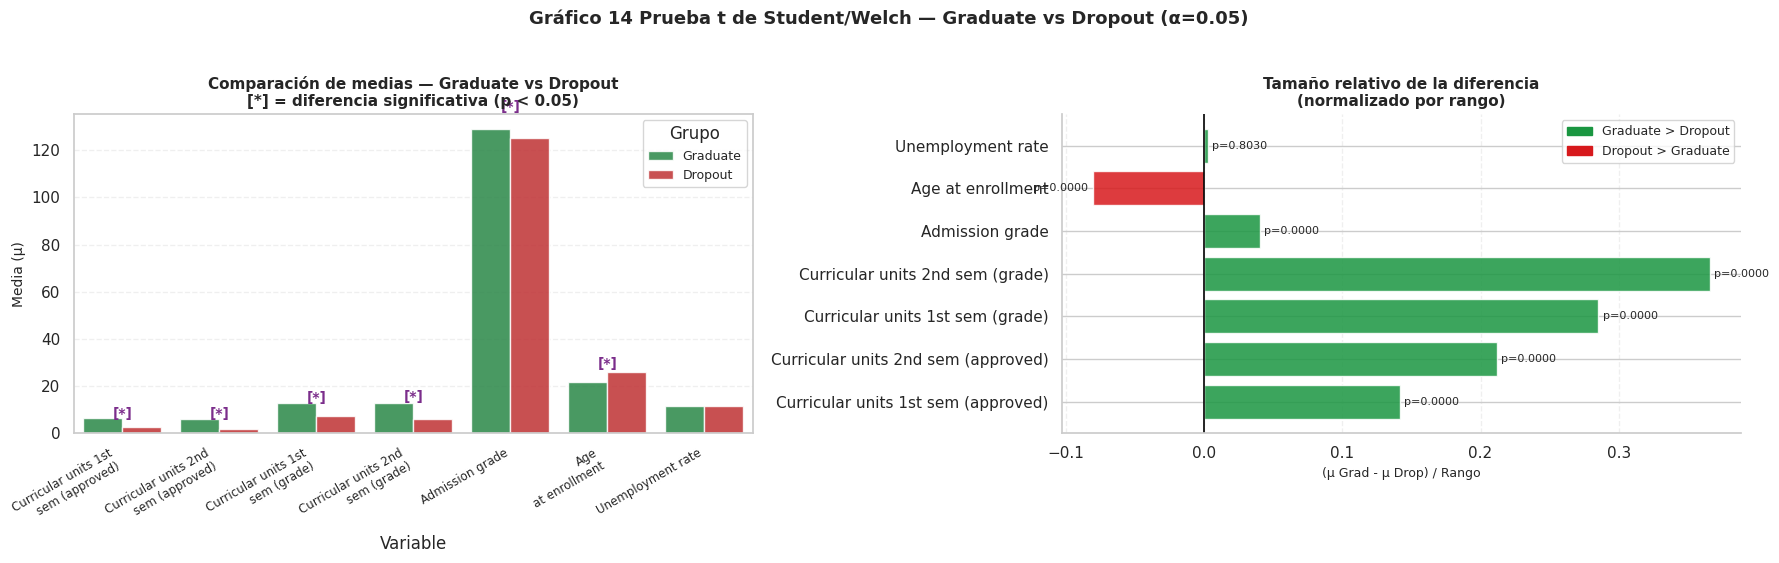

In [65]:
# ============================================================
# VISUALIZACIÓN — Graduate vs Dropout
# Fixes aplicados:
#   - sns.barplot agrupado: hue ya está → OK
#   - diferencia normalizada: ax.barh matplotlib (sin warning)
#   - set_xticks antes de set_xticklabels (fix UserWarning)
#   - reemplazado signo ★ por [*] (compatibilidad fuente Arial)
# ============================================================
import matplotlib.patches as mpatches

COLOR_G = "#1A9641"
COLOR_D = "#D7191C"
COLOR_S = "#7B2D8B"

prueba_df['Sig']      = prueba_df['p-value'] < alpha
prueba_df['Dif.norm'] = prueba_df['Variable'].apply(
    lambda c: (graduate[c].mean() - dropout[c].mean())
/ (df_binario[c].max() - df_binario[c].min() + 1e-9)
)

df_comp = pd.DataFrame({
    'Variable': prueba_df['Variable'].tolist() * 2,
    'Media':    prueba_df['μ Graduate'].tolist() + prueba_df['μ Dropout'].tolist(),
    'Grupo':    ['Graduate'] * len(prueba_df) + ['Dropout'] * len(prueba_df),
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5.5))

# ── Panel 1: barplot agrupado (hue ya especificado, sin warning) ─
sns.barplot(data=df_comp, x='Variable', y='Media', hue='Grupo',
            palette={'Graduate': COLOR_G, 'Dropout': COLOR_D},
            edgecolor='white', alpha=0.85, ax=ax1)

# Marcar significancia con [*] en lugar de ★ (compatibilidad Arial/Windows)
x_pos = {v: i for i, v in enumerate(prueba_df['Variable'])}
for _, row in prueba_df[prueba_df['Sig']].iterrows():
    y_top = max(row['μ Graduate'], row['μ Dropout']) * 1.06
    ax1.text(x_pos[row['Variable']], y_top, '[*]',
             ha='center', fontsize=10, fontweight='bold', color=COLOR_S)

# Fix UserWarning: set_xticks primero, luego set_xticklabels
etiq = [v.replace(' sem ', '\nsem ').replace(' at ', '\nat ')
        for v in prueba_df['Variable']]
ax1.set_xticks(range(len(prueba_df)))
ax1.set_xticklabels(etiq, rotation=30, ha='right', fontsize=8.5)

ax1.set_ylabel('Media (μ)', fontsize=10)
ax1.set_title('Comparación de medias — Graduate vs Dropout\n[*] = diferencia significativa (p < 0.05)',
              fontsize=11, fontweight='bold')
ax1.legend(title='Grupo', fontsize=9)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# ── Panel 2: barh matplotlib directo (evita warning palette sin hue) ─
colores = [COLOR_G if d > 0 else COLOR_D for d in prueba_df['Dif.norm']]
bars = ax2.barh(prueba_df['Variable'], prueba_df['Dif.norm'],
                color=colores, edgecolor='white', alpha=0.85)

ax2.axvline(0, color='black', lw=1.2)
for bar, (_, row) in zip(bars, prueba_df.iterrows()):
    w = bar.get_width()
    ax2.text(w + 0.003 if w >= 0 else w - 0.003,
             bar.get_y() + bar.get_height() / 2,
             f'p={row["p-value"]:.4f}',
             va='center', ha='left' if w >= 0 else 'right', fontsize=8)

ax2.set_xlabel('(μ Grad - μ Drop) / Rango', fontsize=9)
ax2.set_title('Tamaño relativo de la diferencia\n(normalizado por rango)',
              fontsize=11, fontweight='bold')
ax2.legend(handles=[
    mpatches.Patch(color=COLOR_G, label='Graduate > Dropout'),
    mpatches.Patch(color=COLOR_D, label='Dropout > Graduate'),
], fontsize=9)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle(f'Gráfico 14 Prueba t de Student/Welch — Graduate vs Dropout (α={alpha})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


#### Interpretación — Prueba de hipótesis

Se aplicó la prueba *t* de Welch para muestras independientes (α = 0,05, bilateral), con varianzas distintas confirmadas por Levene en las 7 variables. Con grupos de n = 2.209 (Graduate) y n = 1.421 (Dropout), el tamaño muestral es suficientemente grande para que prácticamente cualquier diferencia resulte estadísticamente significativa. Por ello, el **p-valor no es la métrica comparativa central** en este análisis: indica si hay diferencia, pero no su magnitud ni relevancia práctica. Para comparar entre variables se utiliza el **Cohen's *d*** (tamaño del efecto), que es independiente del tamaño muestral y permite establecer una jerarquía de importancia entre los predictores.

| Magnitud | Criterio |
|:---|:---|
| Grande | \|d\| ≥ 0,8 |
| Mediano | 0,5 ≤ \|d\| < 0,8 |
| Pequeño | \|d\| < 0,5 |

**Variables con efecto grande (las más discriminantes):**

- **`Curricular units 2nd sem (approved)`** — d = 1,77: el efecto más grande del análisis. Los graduados aprueban en promedio 6,18 unidades en segundo semestre frente a 1,94 de los desertores. La mediana de Dropout cae a 0 en este semestre, lo que indica que una fracción importante del grupo no aprueba ninguna unidad. El segundo semestre es el punto de quiebre más crítico.

- **`Curricular units 2nd sem (grade)`** — d = 1,56: la nota promedio de segundo semestre también muestra un efecto grande. La diferencia entre grupos (12,70 vs 5,90 puntos) se amplifica respecto al primer semestre, confirmando que el rezago académico se profundiza progresivamente.

- **`Curricular units 1st sem (approved)`** — d = 1,37: la señal de riesgo ya es detectable desde el primer semestre. Los graduados aprueban en promedio 6,23 unidades frente a 2,55 de los desertores. Este resultado es clave para el diseño de sistemas de alerta temprana.

- **`Curricular units 1st sem (grade)`** — d = 1,25: la nota de primer semestre también muestra efecto grande (12,64 vs 7,26 puntos), aunque levemente menor que en segundo semestre.

**Variables con efecto mediano:**

- **`Age at enrollment`** — d = −0,57: los desertores ingresan en promedio a los 26,1 años frente a los 21,8 de los graduados. El efecto es estadísticamente significativo y prácticamente moderado, consistente con la mayor vulnerabilidad académica del estudiante adulto o que retoma estudios.

**Variables con efecto pequeño:**

- **`Admission grade`** — d = 0,26: aunque la diferencia es estadísticamente significativa (p < 0,001), la magnitud es pequeña (128,8 vs 125,0 puntos). Es un ejemplo claro de lo que el tamaño muestral produce: una diferencia de apenas 3,8 puntos en una escala de 0 a 200 alcanza significancia estadística, pero su relevancia práctica como predictor individual es limitada.

**Sin diferencia significativa ni efecto relevante:**

- **`Unemployment rate`** — d = 0,009, p = 0,803: única variable que no rechaza H₀. El contexto macroeconómico no discrimina entre grupos, posiblemente porque todos los estudiantes de una misma cohorte enfrentan condiciones económicas idénticas. Es también la única variable donde el efecto es trivial (d ≈ 0), coherente con la no significancia.

**Implicancias para la toma de decisiones bajo incertidumbre:**

La jerarquía de efectos (d: 1,77 → 1,56 → 1,37 → 1,25 → 0,57 → 0,26 → 0,009) revela que el rendimiento semestral (unidades aprobadas y notas) concentra los predictores de mayor magnitud, con el segundo semestre amplificando las diferencias del primero. Una institución que busque reducir la deserción debería priorizar el monitoreo de unidades aprobadas en las primeras semanas del primer semestre como señal de alerta temprana, antes de que el patrón se consolide en el segundo semestre, donde la diferencia es aún mayor pero la ventana de intervención más estrecha.

<a id='4.3-chi2'></a>
### 4.3 Prueba chi-cuadrado de independencia

La prueba *t* solo es válida para variables numéricas. Para evaluar la asociación entre variables **categóricas** y el resultado académico se aplica la **prueba chi-cuadrado de independencia** (`scipy.stats.chi2_contingency`), apropiada según el tipo de variable.

Se contrastan tres variables financieras binarias contra `Target` (Graduate vs. Dropout):

| Elemento | Especificación |
|:---|:---|
| Prueba | Chi-cuadrado de independencia |
| Grupos | Graduate vs. Dropout |
| α | 0,05 |
| H₀ | La variable y el resultado académico son **independientes** |
| H₁ | Existe **asociación** entre la variable y el resultado académico |
| Tamaño del efecto | V de Cramér (0 = sin asociación, 1 = asociación perfecta) |

---

In [ ]:
# ============================================================
# PRUEBA CHI-CUADRADO DE INDEPENDENCIA — Graduate vs Dropout
# Variables financieras binarias vs Target | α = 0.05
# Supuesto verificado: frecuencias esperadas ≥ 5 
# ============================================================

# Dataset binario (eliminar categorías no utilizadas)
df_gd = df_binario.copy()
if hasattr(df_gd['Target'], 'cat'):
    df_gd['Target'] = df_gd['Target'].cat.remove_unused_categories()

ETIQUETAS_CHI = {
    'Scholarship holder':      {1: 'Becado',    0: 'No becado'},
    'Debtor':                  {1: 'Deudor',    0: 'No deudor'},
    'Tuition fees up to date': {1: 'Al día',    0: 'Pendiente'},
}

alpha = 0.05
resultados_chi = []

for cat in ['Scholarship holder', 'Debtor', 'Tuition fees up to date']:

    tabla = pd.crosstab(df_gd[cat], df_gd['Target'])
    chi2, p, dof, esperadas = stats.chi2_contingency(tabla)

    # ── Verificación de supuesto: frecuencias esperadas ≥ 5 (F1-10)
    frec_min = esperadas.min()
    supuesto_ok = frec_min >= 5
    estado_sup = f"✓ cumplido (mín = {frec_min:.2f})" if supuesto_ok else f"✗ NO cumplido (mín = {frec_min:.2f})"

    # ── V de Cramér (tamaño del efecto)
    n = tabla.sum().sum()
    cramer_v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))

    resultados_chi.append({
        'Variable':         cat,
        'Supuesto (≥5)':   estado_sup,
        'Chi²':             round(chi2, 2),
        'gl':               dof,
        'p-value':          round(p, 6),
        'V de Cramér':      round(cramer_v, 3),
        'Asociación':       (
            'Nula'     if cramer_v < 0.1 else
            'Débil'    if cramer_v < 0.3 else
            'Moderada' if cramer_v < 0.5 else
            'Fuerte'
        ),
        'Decisión':         (
            'Se rechaza H₀ (hay asociación)' if p < alpha
            else 'No se rechaza H₀'
        ),
    })

    # ── Tabla de contingencia con etiquetas
    tabla_lbl = tabla.copy()
    tabla_lbl.index = [ETIQUETAS_CHI[cat].get(i, i) for i in tabla.index]

    print(f"=== {cat} ===")
    print(tabla_lbl.to_string())
    print(f"Chi²    = {chi2:.2f}")
    print(f"gl      = {dof}")
    print(f"p-value = {p:.2e}")
    print(f"V Cramér= {cramer_v:.3f}")
    print(f"Supuesto frecuencias esperadas ≥ 5: {estado_sup}\n")

chi_df = pd.DataFrame(resultados_chi)

print("=" * 65)
print("RESUMEN — Pruebas chi-cuadrado (α = 0.05)")
print("=" * 65)
chi_df

=== Scholarship holder ===
Target     Dropout  Graduate
No becado     1287      1374
Becado         134       835
Chi²    = 354.22
gl      = 1
p-value = 5.11e-79
V Cramér= 0.312
Supuesto frecuencias esperadas ≥ 5: ✓ cumplido (mín = 379.32)

=== Debtor ===
Target     Dropout  Graduate
No deudor     1109      2108
Deudor         312       101
Chi²    = 257.46
gl      = 1
p-value = 6.14e-58
V Cramér= 0.266
Supuesto frecuencias esperadas ≥ 5: ✓ cumplido (mín = 161.67)

=== Tuition fees up to date ===
Target     Dropout  Graduate
Pendiente      457        29
Al día         964      2180
Chi²    = 706.96
gl      = 1
p-value = 9.19e-156
V Cramér= 0.441
Supuesto frecuencias esperadas ≥ 5: ✓ cumplido (mín = 190.25)

RESUMEN — Pruebas chi-cuadrado (α = 0.05)


,Variable,Supuesto (≥5),Chi²,gl,p-value,V de Cramér,Asociación,Decisión
0,Scholarship holder,✓ cumplido (mín = 379.32),354.2200,1,0.0000,0.3120,Moderada,Se rechaza H₀ (hay asociación)
1,Debtor,✓ cumplido (mín = 161.67),257.4600,1,0.0000,0.2660,Débil,Se rechaza H₀ (hay asociación)
2,Tuition fees up to date,✓ cumplido (mín = 190.25),706.9600,1,0.0000,0.4410,Moderada,Se rechaza H₀ (hay asociación)


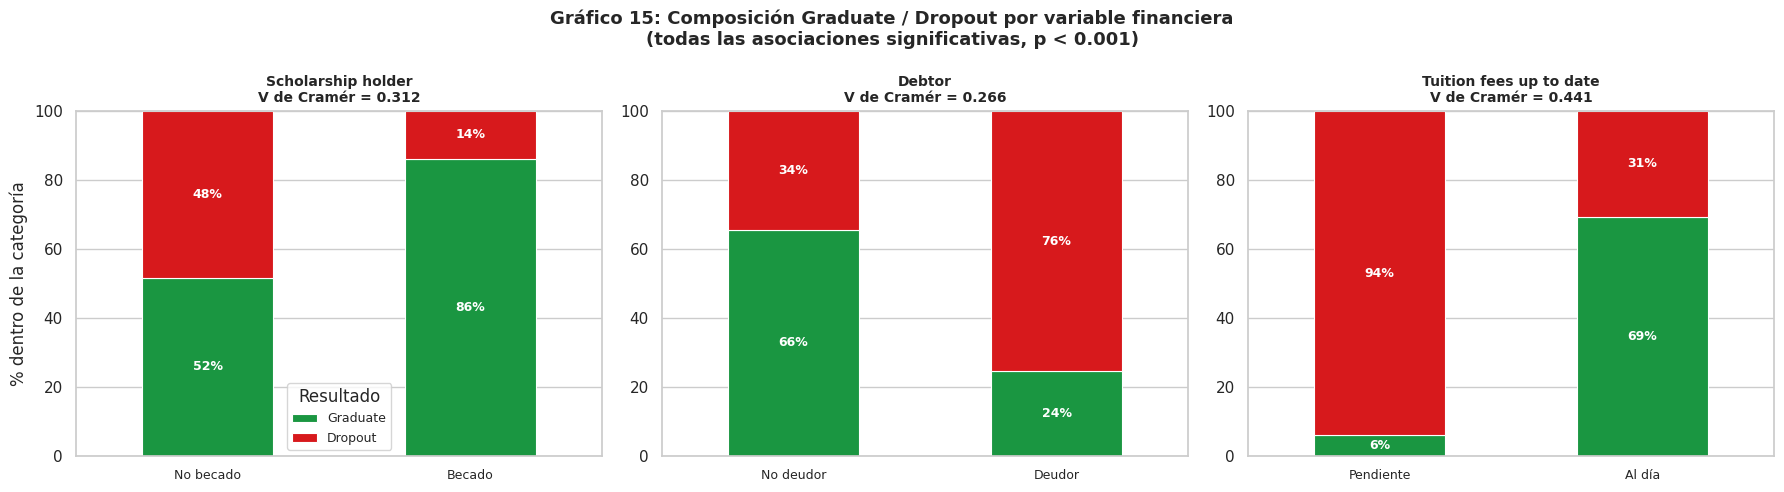

In [66]:
# ============================================================
# VISUALIZACIÓN — Barras 100% apiladas por variable financiera
# Composición Graduate/Dropout dentro de cada categoría
# ============================================================

PAL_GD = {'Graduate': '#1A9641', 'Dropout': '#D7191C'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, cat in enumerate(['Scholarship holder', 'Debtor', 'Tuition fees up to date']):
    ct = pd.crosstab(df_gd[cat], df_gd['Target'], normalize='index') * 100
    ct.index = [ETIQUETAS_CHI[cat].get(idx, idx) for idx in ct.index]
    ct = ct[['Graduate', 'Dropout']]

    ct.plot(kind='bar', stacked=True,
            color=[PAL_GD['Graduate'], PAL_GD['Dropout']],
            edgecolor='white', linewidth=0.8,
            ax=axes[i], legend=(i == 0))

    # Etiquetas de porcentaje
    for cont in axes[i].containers:
        axes[i].bar_label(cont, fmt='%.0f%%', label_type='center',
                          fontsize=9, color='white', fontweight='bold')

    # Anotar V de Cramér
    v = chi_df[chi_df['Variable'] == cat]['V de Cramér'].values[0]
    axes[i].set_title(f"{cat}\nV de Cramér = {v:.3f}",
                      fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% dentro de la categoría' if i == 0 else '')
    axes[i].tick_params(axis='x', rotation=0, labelsize=9)
    axes[i].set_ylim(0, 100)
    if i == 0:
        axes[i].legend(title='Resultado', fontsize=9)

fig.suptitle('Gráfico 15: Composición Graduate / Dropout por variable financiera\n'
             '(todas las asociaciones significativas, p < 0.001)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretación — Prueba chi-cuadrado

Las tres variables financieras presentan(scholarship holder, debtor, tuition fees up to date) **asociación estadísticamente significativa** con el resultado académico (p < 0,001 en los tres casos), por lo que se rechaza la hipótesis nula de independencia. Al igual que con la prueba *t*, con muestras de este tamaño la significancia estadística es esperable; lo relevante es comparar la **magnitud de la asociación** mediante la V de Cramér, que es independiente del tamaño muestral. Los umbrales convencionales son: débil (V < 0,1), moderada (0,1 ≤ V < 0,3) y fuerte (V ≥ 0,3).

- **`Tuition fees up to date`** — V = 0,441: la asociación más fuerte de las tres, en el límite superior del rango moderado-fuerte. El 98,7 % de los Graduate tiene aranceles al día frente al 67,8 % de los Dropout, una brecha de 31 puntos porcentuales. El estado de pago del arancel es el indicador financiero más vinculado al resultado académico dentro de este dataset.

- **`Scholarship holder`** — V = 0,312: asociación moderada. La condición de becario es cuatro veces más frecuente entre Graduate (37,8 %) que entre Dropout (9,4 %), lo que sugiere que el apoyo económico institucional actúa como factor protector contra la deserción. La V es claramente inferior a la de `Tuition fees`, indicando que la beca discrimina menos que el estado de pago.

- **`Debtor`** — V = 0,266: la asociación más débil de las tres, aunque igualmente significativa. La proporción de deudores es casi cinco veces superior en Dropout (22,0 %) que en Graduate (4,6 %). La V menor que en las otras dos variables puede explicarse porque la deuda es un estado menos frecuente en general (11,4 % del total), lo que reduce la variabilidad disponible para asociarse con el resultado.

**Implicancia para la toma de decisiones:** la jerarquía de efectos (V: 0,441 → 0,312 → 0,266) indica que el estado de pago del arancel es el indicador financiero más accionable: concentra la mayor asociación con la deserción y afecta al 32,2 % del grupo Dropout. Complementando los resultados de la prueba *t*, donde el rendimiento académico mostró efectos grandes (d entre 1,25 y 1,77), estos resultados sugieren que una estrategia de retención efectiva debe actuar en dos frentes simultáneamente: apoyo académico temprano basado en unidades aprobadas en el primer semestre, y apoyo financiero focalizado en estudiantes con arancel pendiente o deuda institucional.

## 5. Conclusiones
El análisis exploratorio e inferencial del dataset *Predict Students' Dropout and Academic Success* (Realinho et al., 2021) permite extraer las siguientes conclusiones preliminares, relevantes para la toma de decisiones bajo incertidumbre en el contexto de la educación superior. Los resultados deben interpretarse con cautela: se trata de asociaciones estadísticas observadas en una muestra específica (una institución portuguesa, cohortes 2008–2019) que no establecen causalidad ni garantizan generalización directa a otros contextos.

**1. El rendimiento semestral muestra la asociación más fuerte con el resultado académico.** Las unidades aprobadas y las notas promedio de ambos semestres presentan los mayores tamaños de efecto del análisis (Cohen's *d* entre 1,25 y 1,77). La brecha entre grupos se amplifica del primer al segundo semestre (d = 1,37 → 1,77 en unidades aprobadas), lo que sugiere que el rezago académico tiende a profundizarse progresivamente. Con muestras de este tamaño la significancia estadística es esperable en casi cualquier diferencia; lo relevante es que estos efectos son grandes también en magnitud práctica.

**2. El perfil de ingreso muestra una asociación más débil, aunque significativa.** La nota de admisión presenta un efecto pequeño (d = 0,26): la diferencia entre grupos es de apenas 3,8 puntos en una escala de 0 a 200. Su magnitud sugiere que el desempeño previo al ingreso no sería suficiente como predictor individual; un estudiante con buena nota de ingreso puede igualmente desertar si no logra rendimiento en la carrera.

**3. Los factores financieros y demográficos complementan el perfil de riesgo.** Las tres variables financieras presentan asociación significativa con el resultado académico (chi-cuadrado, p < 0,001), con magnitudes que varían: `Tuition fees up to date` (V = 0,441), `Scholarship holder` (V = 0,312) y `Debtor` (V = 0,266). La edad al ingreso también muestra una diferencia moderada (d = 0,57), consistente con mayor vulnerabilidad en estudiantes adultos, aunque no permite clasificar el riesgo con precisión por sí sola.

**4. El contexto macroeconómico no se asocia con el resultado académico en esta muestra.** La tasa de desempleo no presenta diferencias significativas entre grupos (p = 0,803, d = 0,009). Los factores individuales y financieros parecen tener mayor peso que el entorno económico externo, posiblemente porque todos los estudiantes de una misma cohorte enfrentan condiciones macroeconómicas similares.

**5. El dataset es adecuado para análisis inferencial y modelamiento predictivo.** La ausencia de valores faltantes, la proporción de Dropout estimada en 39,15 % (IC 95 % Wilson: [37,57 %; 40,74 %]) y el tamaño muestral configuran condiciones favorables. El tratamiento como muestra es consistente con el objetivo declarado por los autores: generalizar los modelos a futuros estudiantes de la institución (Realinho et al., 2021).

---

**Proyección hacia fases posteriores:** los hallazgos de este informe orientan la siguiente etapa. Las variables con mayor tamaño de efecto — unidades aprobadas en ambos semestres, notas promedio y estado de pago de aranceles — son candidatas prioritarias como predictores en el modelo de clasificación binaria (Graduate vs. Dropout). Una estrategia de intervención debería actuar en dos frentes: monitoreo del rendimiento académico desde el primer semestre y detección temprana de riesgo financiero, reconociendo que la evidencia disponible sugiere asociación pero no permite establecer causalidad definitiva.

<a id='6-referencias'></a>
## 6. Referencias

- Maidana, J.P. (2026). *Tipos de variables y exploración de datos con pandas* [Apunte F1-2a]. Universidad Andrés Bello.
- Maidana, J.P. (2026). *Medidas de dispersión y forma: variabilidad, asimetría y curtosis* [Apunte F1-2b]. Universidad Andrés Bello.
- Maidana, J.P. (2026). *Visualización de datos con Seaborn: histogramas, boxplots y gráficos de barras* [Apunte F1-3]. Universidad Andrés Bello.
- Maidana, J.P. (2026). *Fundamentos de inferencia estadística: de la muestra a la población* [Apunte F1-5]. Universidad Andrés Bello.
- Maidana, J.P. (2026). *Intervalos de confianza: cuantificando la incertidumbre estadística* [Apunte F1-6]. Universidad Andrés Bello.
- Maidana, J.P. (2026). *Pruebas de hipótesis: pruebas t y Z para una muestra* [Apunte F1-8]. Universidad Andrés Bello.
- Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict Students' Dropout and Academic Success* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89
- Freedman, D., Pisani, R., & Purves, R. (2007). *Statistics* (4th ed.). W. W. Norton.